In [ ]:
!pip install seaborn scikit-learn tensorflow numpy pandas matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
COLUMN_GROUPS = {
    'battery_target': [
        'remainPowerPercent',   # SOC — State of Charge
        'remainLifePercent',    # SOH — State of Health
    ],

    'battery_electrical': [
        'voltage(v)',
        'currentVoltage',
        'currentCurrent',
        'currentElectricity',
        'batteryTemperature',
    ],

    'battery_cells': [
        'Battery_Cell1', 'Battery_Cell2', 'Battery_Cell3',
        'Battery_Cell4', 'Battery_Cell5', 'Battery_Cell6',
    ],

    'battery_health_static': [
        'dischargeCount',                  # циклы заряда
        'CENTER_BATTERY.fullCapacity',     # реальная ёмкость сейчас (мАч)
        'CENTER_BATTERY.productDate',      # возраст батареи
        'BatterySerialNumber',             # идентификатор батареи
    ],

    'flight_dynamics': [
        'altitude(feet)', 'ascent(feet)',
        'speed(mph)',
        'velocityX(mph)', 'velocityY(mph)', 'velocityZ(mph)',
        'pitch(deg)', 'roll(deg)', 'yaw(deg)',
        'distance(feet)',
    ],

    'rc_controls': [
        'Rc_throttle',
        'Rc_elevator', 'Rc_aileron', 'Rc_rudder', 'Rc_gyro',
        'powerlevel',
    ],

    'environment': [
        'pressure(Pa)',
        'temperature(F)',
        'satellites',
        'downlinkSignalQuality',
        'uplinkSignalQuality',
    ],

    'flight_state': [
        'flightmode', 'flyState',
        'isflying', 'isMotorsOn',
        'istakingphoto', 'isTakingVideo',
    ],

    'time': [
        'time(millisecond)',
        'datetime(utc)',
        'timestamp',
    ]
}
cell_cols = ['Battery_Cell1','Battery_Cell2','Battery_Cell3',
             'Battery_Cell4','Battery_Cell5','Battery_Cell6']

In [ ]:
# !ls "/content/drive/MyDrive"
!unzip /content/drive/MyDrive/CSV.zip

Archive:  /content/drive/MyDrive/CSV.zip
   creating: CSV/
  inflating: CSV/2017-07-07_15-11-17_v2.csv  
  inflating: CSV/2017-07-07_15-14-42_v2.csv  
  inflating: CSV/2017-07-07_15-17-57_v2.csv  
  inflating: CSV/2017-07-07_15-20-42_v2.csv  
  inflating: CSV/2017-07-07_15-23-04_v2.csv  
  inflating: CSV/2017-07-07_15-34-06_v2.csv  
  inflating: CSV/2017-07-21_18-29-40_v2.csv  
  inflating: CSV/2017-07-21_18-37-40_v2.csv  
  inflating: CSV/2017-07-21_18-46-57_v2.csv  
  inflating: CSV/2017-07-21_19-01-51_v2.csv  
  inflating: CSV/2017-07-21_19-05-41_v2.csv  
  inflating: CSV/2017-07-26_11-47-19_v2.csv  
  inflating: CSV/2017-07-26_11-50-14_v2.csv  
  inflating: CSV/2017-07-26_11-54-41_v2.csv  
  inflating: CSV/2017-07-28_14-49-12_v2.csv  
  inflating: CSV/2017-07-28_14-50-46_v2.csv  
  inflating: CSV/2017-07-28_14-54-11_v2.csv  
  inflating: CSV/2017-07-28_14-56-17_v2.csv  
  inflating: CSV/2017-08-10_17-28-11_v2.csv  
  inflating: CSV/2017-08-10_17-30-22_v2.csv  
  inflating: CSV/2017

In [ ]:
import pandas as pd
from pathlib import Path

folder_path = Path("./CSV")

df_list = []
file_id = 0

phase2code = {
    "climb": 1,
    "cruise": 2,
    "descent": 3,
    "motorsOn": 1
}

for file in folder_path.glob("*.csv"):
  try:
    temp_df = pd.read_csv(file)
    temp_df['dt_hours'] = temp_df['timestamp'].diff() / 3600
    temp_df['file_id'] = file_id
    temp_df['velX_ms'] = temp_df['velocityX(mph)']   * 0.44704
    temp_df['velY_ms'] = temp_df['velocityY(mph)']   * 0.44704
    temp_df['velZ_ms'] = temp_df['velocityZ(mph)']   * 0.44704
    temp_df['altitude_m'] = temp_df['altitude(feet)']  * 0.3048
    # Временной шаг (сек)
    dt = temp_df['time(millisecond)'].diff() / 1000
    temp_df['dt_sec'] = dt.where(dt > 1e-6, np.nan)
    # Горизонтальная и вертикальная скорость
    temp_df['speed_horizontal'] = np.sqrt(
        temp_df['velX_ms']**2 + temp_df['velY_ms']**2
    )
    temp_df['speed_vertical'] = temp_df['velZ_ms'] * -1

    temp_df['acc_horizontal'] = temp_df['speed_horizontal'].diff() / temp_df['dt_sec']
    temp_df['acc_vertical'] = temp_df['speed_vertical'].diff() / temp_df['dt_sec']

    temp_df['acc_total'] = np.sqrt(
        temp_df['acc_horizontal']**2 + temp_df['acc_vertical']**2
    )

    EPS = 0.6

    conditions = [
        temp_df['velZ_ms'] * -1 > EPS,
        temp_df['velZ_ms'] * -1 < -EPS,
        (temp_df['speed_horizontal'] < EPS) & (temp_df['altitude_m'] < 1)
    ]

    choices = ['climb', 'descent', 'motorsOn']

    temp_df['phase'] = np.select(
        conditions,
        choices,
        default='cruise'
    )
    temp_df['phase_code'] = temp_df['phase'].map(phase2code)
    file_id += 1
    df_list.append(temp_df)
  except Exception as ex:
    print(ex)
    continue

df = pd.concat(df_list, ignore_index=True)

print(f"Загружено файлов: {len(df_list)}")
print(f"Размер: {df.shape}")

No columns to parse from file


/tmp/ipykernel_1512/2624579179.py:18: DtypeWarning: Columns (51,52,53,54,56) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
/tmp/ipykernel_1512/2624579179.py:18: DtypeWarning: Columns (51,52,53,54,56) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Загружено файлов: 398
Размер: (1183594, 103)


In [ ]:
df_0 = df[df['file_id'] == 0]
print(df_0.columns.tolist())
print(df_0.head())
print(df_0.dtypes)

['latitude', 'longitude', 'altitude(feet)', 'ascent(feet)', 'speed(mph)', 'distance(feet)', 'max_altitude(feet)', 'max_ascent(feet)', 'max_speed(mph)', 'max_distance(feet)', 'time(millisecond)', 'datetime(utc)', 'datetime(local)', 'satellites', 'pressure(Pa)', 'temperature(F)', 'voltage(v)', 'home_latitude', 'home_longitude', 'velocityX(mph)', 'velocityY(mph)', 'velocityZ(mph)', 'pitch(deg)', 'roll(deg)', 'yaw(deg)', 'powerlevel', 'isflying', 'istakingphoto', 'remainPowerPercent', 'remainLifePercent', 'currentCurrent', 'currentElectricity', 'currentVoltage', 'batteryTemperature', 'dischargeCount', 'flightmode', 'isMotorsOn', 'isTakingVideo', 'Rc_elevator', 'Rc_aileron', 'Rc_throttle', 'Rc_rudder', 'Rc_gyro', 'timestamp', 'Battery_Cell1', 'Battery_Cell2', 'Battery_Cell3', 'Battery_Cell4', 'Battery_Cell5', 'Battery_Cell6', 'Dronetype', 'AppVersion', 'Planename', 'FlyControllerSerialNumber', 'RemoteSerialNumber', 'BatterySerialNumber', 'CENTER_BATTERY.productDate', 'CENTER_BATTERY.serialN

In [ ]:
print(f"Записей: {len(df_0)}")
print(f"Длительность полёта: {df_0['time(millisecond)'].max()/60000:.1f} мин")
print(f"\nПропуски:\n{df_0.isnull().sum()[df.isnull().sum()>0]}")

print("\nSOC (remainPowerPercent):",
      df_0['remainPowerPercent'].max(), "->", df_0['remainPowerPercent'].min())
print("SOH (remainLifePercent):",
      df_0['remainLifePercent'].min(), "->", df_0['remainLifePercent'].max())
print("Циклов заряда:", df_0['dischargeCount'].unique())
print("Полная ёмкость (мАч):", df_0['CENTER_BATTERY.fullCapacity'].unique())

# Разбаланс ячеек
df['cell_imbalance'] = df[cell_cols].std(axis=1)
print(f"\nМакс разбаланс ячеек: {df['cell_imbalance'].max():.4f} В")

Записей: 3829
Длительность полёта: 6.6 мин

Пропуски:
latitude              0
longitude             0
max_altitude(feet)    0
max_ascent(feet)      0
max_speed(mph)        0
                     ..
speed_horizontal      0
speed_vertical        0
acc_horizontal        1
acc_vertical          1
acc_total             1
Length: 95, dtype: int64

SOC (remainPowerPercent): 96.0 -> 42.0
SOH (remainLifePercent): 78.0 -> 78.0
Циклов заряда: [91.]
Полная ёмкость (мАч): [3448.    0.]

Макс разбаланс ячеек: 147.1172 В


In [ ]:
# Конвертация единиц
df['speed_ms']       = df['speed(mph)']       * 0.44704
df['temp_C']         = (df['temperature(F)'] - 32) * 5/9
df['current_A']  = df['currentCurrent'].abs() / 1000
df['voltage_V']  = df['currentVoltage'] / 1000
df['cell_imbalance_mV'] = (df[cell_cols].max(axis=1) -
                            df[cell_cols].min(axis=1))

# Мощность = U * I
#df['power_W'] = df['currentVoltage'] * np.abs(df['currentCurrent'])
df['power_W'] = (df['currentVoltage'] / 1000) * (df['currentCurrent'].abs() / 1000)

# Разбаланс ячеек (деградация отдельных ячеек)
df['cell_min']       = df[cell_cols].min(axis=1)
df['cell_max']       = df[cell_cols].max(axis=1)

# Эффективность использования ёмкости
df['capacity_used_pct'] = 1 - (df['currentElectricity'] /
                                df['CENTER_BATTERY.fullCapacity'])

# Ток разряда (берём модуль, т.к. разряд — отрицательный ток)
df['current_mA'] = df['currentCurrent'].abs()
df['soc_rate'] = (df['current_mA'] * df['dt_hours'])
#df['soc_rate'] = df['remainPowerPercent'].diff() / \
#                 df['time(millisecond)'].diff().replace(0, np.nan) * 1000
# df['CENTER_BATTERY.fullCapacity'] = (
#     df['CENTER_BATTERY.fullCapacity']
#     .replace(0, np.nan)
#     .ffill()
#     .bfill()
# )
# fullCapacity = df['CENTER_BATTERY.fullCapacity'].iloc[0]
# df['soc_rate'] = df['currentElectricity'] / fullCapacity * 100

# Горизонтальная и вертикальная скорость
df['speed_horizontal'] = np.sqrt(df['velX_ms']**2 + df['velY_ms']**2)
df['speed_vertical']   = df['velZ_ms'].abs()

# Кодирование категориальных признаков
df['flightmode_code'] = df['flightmode'].astype('category').cat.codes
df['flyState_code']   = df['flyState'].astype('category').cat.codes

# Время с начала полёта (секунды)
df['flight_time_s'] = df['time(millisecond)'] / 1000

print(df[['power_W', 'cell_imbalance',
          'capacity_used_pct', 'soc_rate']].describe())

            power_W  cell_imbalance  capacity_used_pct      soc_rate
count  1.183589e+06    1.183588e+06       1.183483e+06  1.183191e+06
mean   3.054517e+02    2.226091e+01               -inf  4.012753e+02
std    9.584938e+01    7.270027e+00                NaN  9.145031e+03
min    0.000000e+00    0.000000e+00               -inf -3.527197e+03
25%    2.918576e+02    1.754613e+01                NaN  1.837267e+02
50%    3.242615e+02    2.173860e+01                NaN  3.895556e+02
75%    3.483109e+02    2.660388e+01                NaN  4.978462e+02
max    6.772457e+02    1.471172e+02       8.001933e-01  9.939380e+06


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


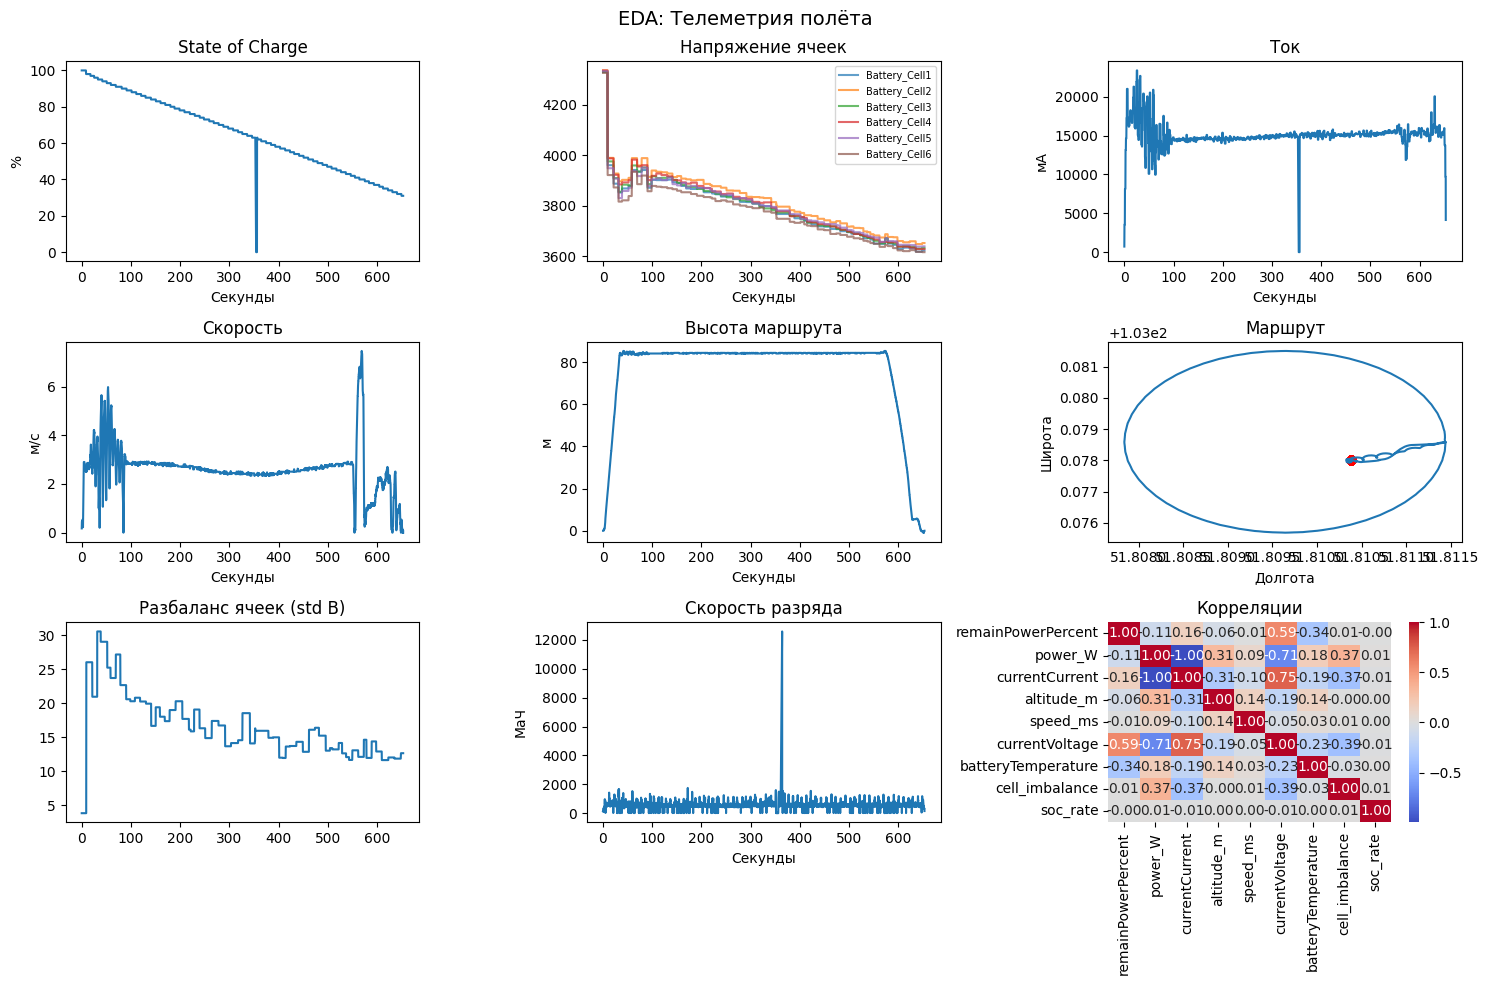

In [ ]:
df_0 = df[df['file_id'] == 394]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

# SOC во времени
axes[0,0].plot(df_0['flight_time_s'], df_0['remainPowerPercent'])
axes[0,0].set_title('State of Charge')
axes[0,0].set_xlabel('Секунды')
axes[0,0].set_ylabel('%')

# Напряжение ячеек
for col in cell_cols:
    axes[0,1].plot(df_0['flight_time_s'], df_0[col], alpha=0.7, label=col)
axes[0,1].set_title('Напряжение ячеек')
axes[0,1].set_xlabel('Секунды')
axes[0,1].legend(fontsize=7)

# Ток потребления
axes[0,2].plot(df_0['flight_time_s'], df_0['current_mA'])
axes[0,2].set_title('Ток')
axes[0,2].set_xlabel('Секунды')
axes[0,2].set_ylabel('мА')

# Скорость
axes[1,0].plot(df_0['flight_time_s'], df_0['speed_ms'])
axes[1,0].set_title('Скорость')
axes[1,0].set_ylabel('м/с')
axes[1,0].set_xlabel('Секунды')


# Высота
axes[1,1].plot(df_0['flight_time_s'], df_0['altitude_m'])
axes[1,1].set_title('Высота маршрута')
axes[1,1].set_ylabel('м')
axes[1,1].set_xlabel('Секунды')

# Маршрут
axes[1,2].plot(df_0['latitude'], df_0['longitude'])
axes[1,2].scatter(df_0['home_latitude'], df_0['home_longitude'], c='red')
axes[1,2].set_title('Маршрут')
axes[1,2].set_ylabel('Широта')
axes[1,2].set_xlabel('Долгота')

# Разбаланс ячеек
axes[2,0].plot(df_0['flight_time_s'], df_0['cell_imbalance'])
axes[2,0].set_title('Разбаланс ячеек (std В)')

# скорость разряда
# ax2 = axes[2, 1].twinx()
axes[2,1].plot(df_0['flight_time_s'], df_0['soc_rate'])
# ax2.plot(df['flight_time_s'], df['altitude_m'])
axes[2,1].set_title('Скорость разряда')
axes[2,1].set_ylabel('МаЧ')
axes[2,1].set_xlabel('Секунды')

# Корреляции
key_cols = ['remainPowerPercent', 'power_W', 'currentCurrent',
            'altitude_m', 'speed_ms', 'currentVoltage',
            'batteryTemperature', 'cell_imbalance', 'soc_rate']
corr = df[key_cols].corr()
sns.heatmap(corr, ax=axes[2,2], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
axes[2,2].set_title('Корреляции')

plt.tight_layout()
plt.savefig('eda_flight.png', dpi=150)
plt.show()

/tmp/ipykernel_1512/4286222146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['soc_rate_smooth'] = df['soc_rate'].rolling(
/tmp/ipykernel_1512/4286222146.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['remaining_time_s'] = (


Text(0.5, 1.0, 'SOC vs Расчётное оставшееся время полёта')

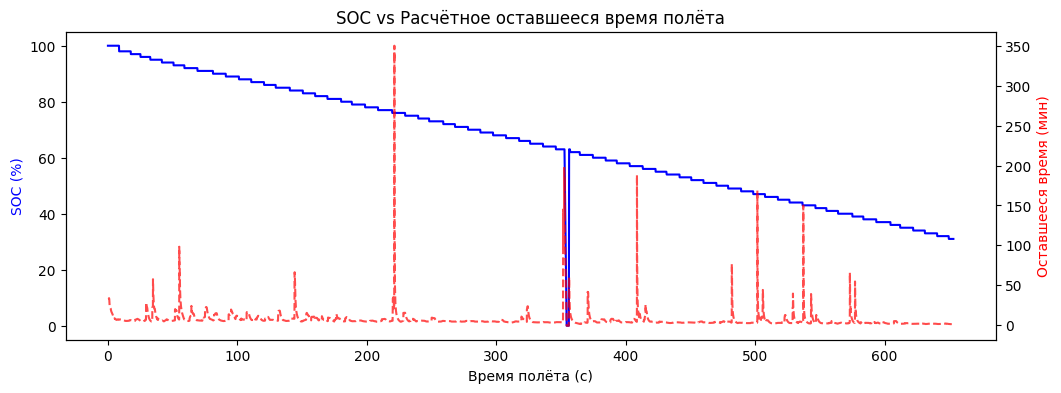

In [ ]:
def estimate_remaining_time(df):
    # Скользящее среднее скорости разряда (% в секунду)
    window = 30  # секунд
    df['soc_rate_smooth'] = df['soc_rate'].rolling(
        window, min_periods=5).mean().abs()

    df['remaining_time_s'] = (
        (df['currentElectricity'] - df['soc_rate_smooth']) / df['soc_rate_smooth'] * 60
    )
    return df

df = estimate_remaining_time(df)
df_0 = estimate_remaining_time(df_0)
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_0['flight_time_s'], df_0['remainPowerPercent'],
         'b-', label='SOC (%)')
ax2 = ax1.twinx()
ax2.plot(df_0['flight_time_s'], df_0['remaining_time_s']/60,
         'r--', label='Остаток (мин)', alpha=0.7)
ax1.set_xlabel('Время полёта (с)')
ax1.set_ylabel('SOC (%)', color='b')
ax2.set_ylabel('Оставшееся время (мин)', color='r')
plt.title('SOC vs Расчётное оставшееся время полёта')

In [ ]:
print(df.columns.values)

['latitude' 'longitude' 'altitude(feet)' 'ascent(feet)' 'speed(mph)'
 'distance(feet)' 'max_altitude(feet)' 'max_ascent(feet)' 'max_speed(mph)'
 'max_distance(feet)' 'time(millisecond)' 'datetime(utc)'
 'datetime(local)' 'satellites' 'pressure(Pa)' 'temperature(F)'
 'voltage(v)' 'home_latitude' 'home_longitude' 'velocityX(mph)'
 'velocityY(mph)' 'velocityZ(mph)' 'pitch(deg)' 'roll(deg)' 'yaw(deg)'
 'powerlevel' 'isflying' 'istakingphoto' 'remainPowerPercent'
 'remainLifePercent' 'currentCurrent' 'currentElectricity'
 'currentVoltage' 'batteryTemperature' 'dischargeCount' 'flightmode'
 'isMotorsOn' 'isTakingVideo' 'Rc_elevator' 'Rc_aileron' 'Rc_throttle'
 'Rc_rudder' 'Rc_gyro' 'timestamp' 'Battery_Cell1' 'Battery_Cell2'
 'Battery_Cell3' 'Battery_Cell4' 'Battery_Cell5' 'Battery_Cell6'
 'Dronetype' 'AppVersion' 'Planename' 'FlyControllerSerialNumber'
 'RemoteSerialNumber' 'BatterySerialNumber' 'CENTER_BATTERY.productDate'
 'CENTER_BATTERY.serialNo' 'CENTER_BATTERY.fullCapacity'
 'CENTER_B

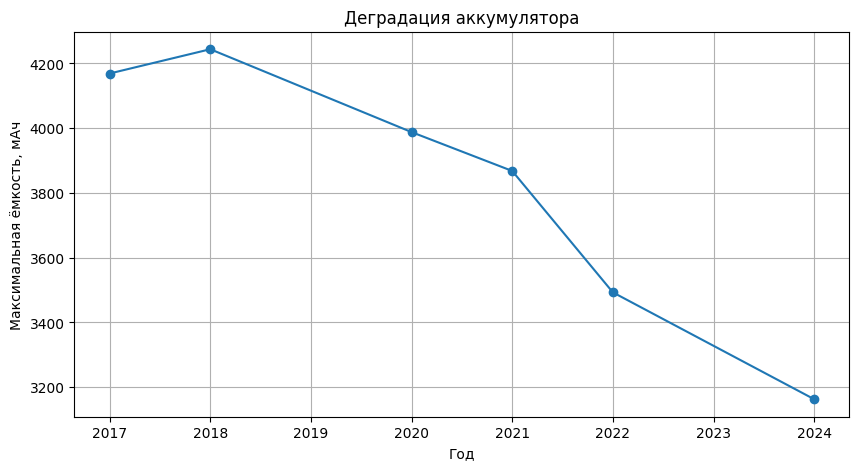

In [ ]:
df['year'] = pd.to_datetime(df['datetime(utc)']).dt.year

year_capacity = (
    df.groupby('year')['currentElectricity']
      .max()
      .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    year_capacity['year'],
    year_capacity['currentElectricity'],
    marker='o'
)

plt.xlabel('Год')
plt.ylabel('Максимальная ёмкость, мАч')
plt.title('Деградация аккумулятора')
plt.grid(True)

plt.show()

In [ ]:
print(df_0['dt_sec'])

1165985      NaN
1165986    0.142
1165987    0.139
1165988    0.115
1165989    0.120
           ...  
1172294    0.110
1172295    0.111
1172296    0.120
1172297    0.109
1172298    0.130
Name: dt_sec, Length: 6314, dtype: float64


Text(0, 0.5, 'm')

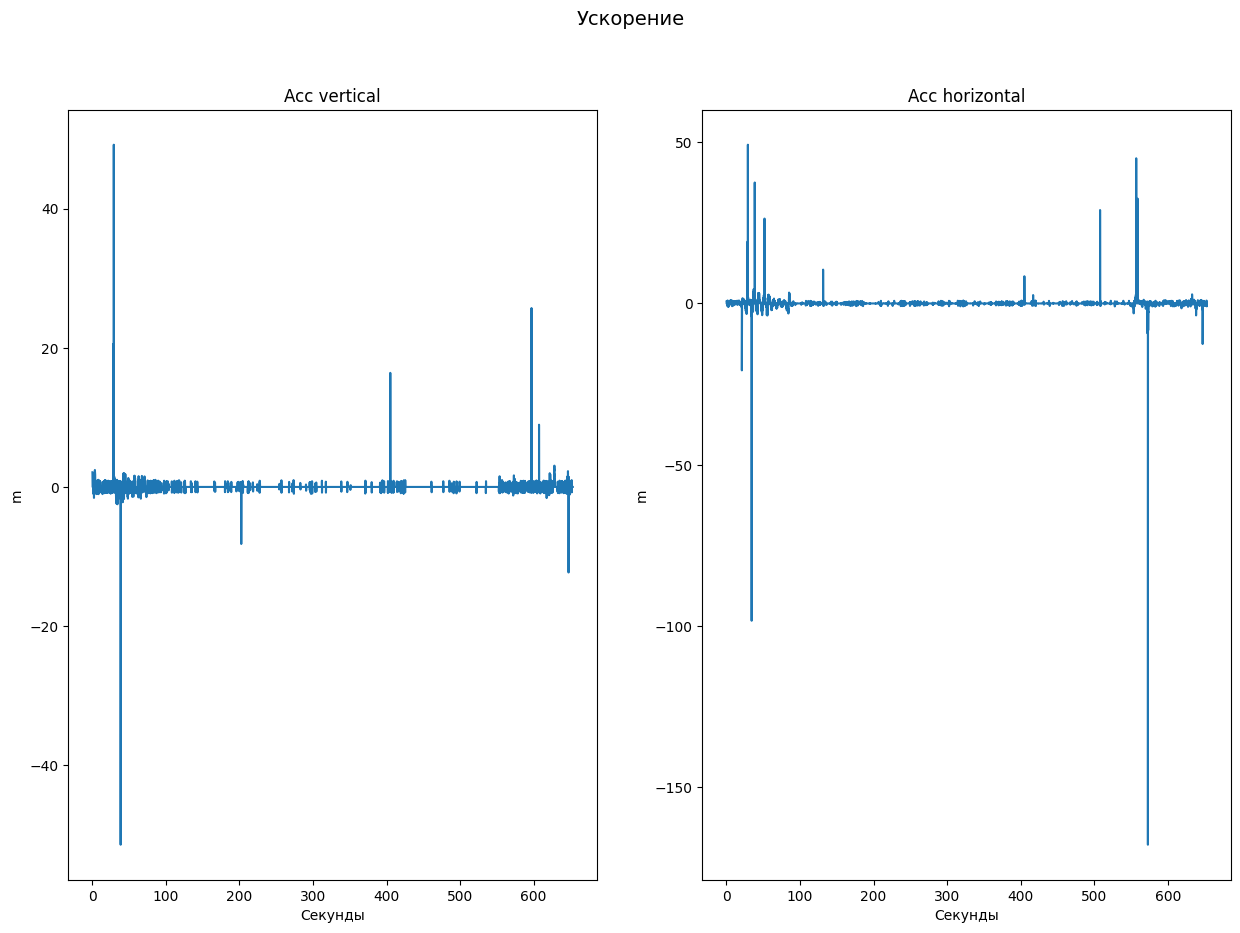

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle('Ускорение', fontsize=14)

# Ускорение по вертикали
axes[0].plot(df_0['flight_time_s'], df_0['acc_vertical'])
axes[0].set_title('Acc vertical')
axes[0].set_xlabel('Секунды')
axes[0].set_ylabel('m')

# Ускорение горизонтальное
axes[1].plot(df_0['flight_time_s'], df_0['acc_horizontal'])
axes[1].set_title('Acc horizontal')
axes[1].set_xlabel('Секунды')
axes[1].set_ylabel('m')


Text(0, 0.5, 'm')

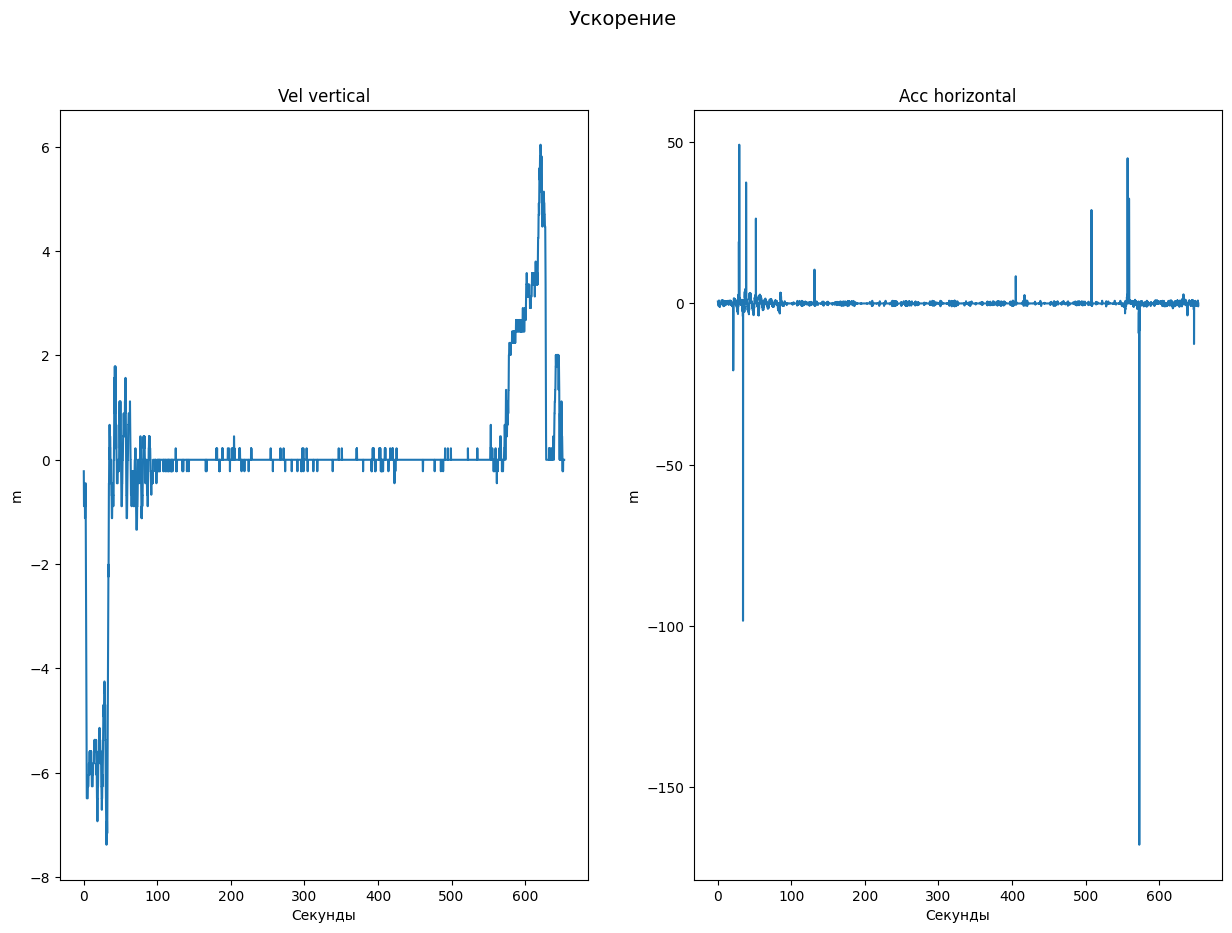

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle('Ускорение', fontsize=14)

# Ускорение по вертикали
axes[0].plot(df_0['flight_time_s'], df_0['velocityZ(mph)'])
axes[0].set_title('Vel vertical')
axes[0].set_xlabel('Секунды')
axes[0].set_ylabel('m')

# Ускорение горизонтальное
axes[1].plot(df_0['flight_time_s'], df_0['acc_horizontal'])
axes[1].set_title('Acc horizontal')
axes[1].set_xlabel('Секунды')
axes[1].set_ylabel('m')


In [ ]:
df_0['altitude_m']

,altitude_m
1165985,0.0
1165986,0.0
1165987,0.0
1165988,0.0
1165989,0.0
...,...
1172294,0.0
1172295,0.0
1172296,0.0
1172297,0.0


In [ ]:
EPS = 0.48

conditions = [
    df_0['velocityZ(mph)'] * -1 > EPS,
    df_0['velocityZ(mph)'] * -1 < -EPS,
    (df_0['speed_horizontal'] < EPS) & (df_0['altitude(feet)'] < 1)
]

choices = ['climb', 'descent', 'motorsOn']

df_0['phase'] = np.select(
    conditions,
    choices,
    default='cruise'
)
df_0['phase']

/tmp/ipykernel_1512/2069754502.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['phase'] = np.select(


,phase
1165985,motorsOn
1165986,climb
1165987,climb
1165988,climb
1165989,climb
...,...
1172294,motorsOn
1172295,motorsOn
1172296,motorsOn
1172297,motorsOn


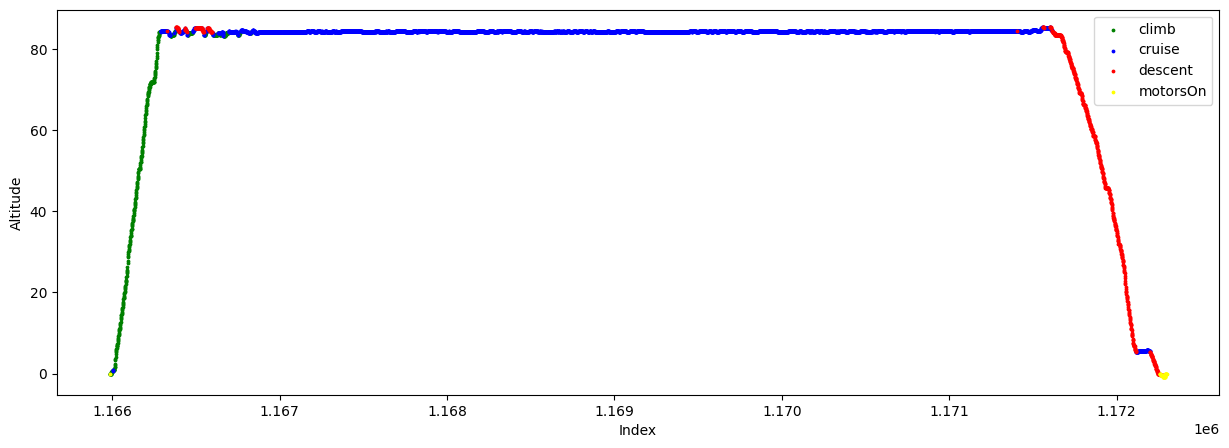

In [ ]:
colors = {
    'climb': 'green',
    'cruise': 'blue',
    'descent': 'red',
    'motorsOn': 'yellow'
}

plt.figure(figsize=(15, 5))

for phase, group in df_0.groupby('phase'):
    plt.scatter(
        group.index,
        group['altitude_m'],
        c=colors[phase],
        s=3,
        label=phase
    )

plt.legend()
plt.xlabel('Index')
plt.ylabel('Altitude')
plt.show()

# Проектирование маршрута

In [ ]:
import pandas as pd

route = pd.read_csv("TEST-GT_4_045_H_020.csv")
route.columns = ["lat", "lon", "alt", "pitch"]
route

FileNotFoundError: [Errno 2] No such file or directory: 'TEST-GT_4_045_H_020.csv'

In [ ]:
vx = 5
vz = 5
vy = 5
flight_time_s = 0
roll = -20

home_lat = 52
home_lon = 103

In [ ]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2, degrees

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def bearing_deg(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = sin(dlon) * cos(lat2)
    y = cos(lat1)*sin(lat2) - sin(lat1)*cos(lat2)*cos(dlon)
    return (degrees(atan2(x, y)) + 360) % 360

def move_point(lat, lon, bearing_d, distance_m):
    R  = 6371000
    br = radians(bearing_d)
    lat1 = radians(lat)
    lon1 = radians(lon)
    lat2 = asin(sin(lat1)*cos(distance_m/R) +
                cos(lat1)*sin(distance_m/R)*cos(br))
    lon2 = lon1 + atan2(
        sin(br)*sin(distance_m/R)*cos(lat1),
        cos(distance_m/R) - sin(lat1)*sin(lat2)
    )
    from math import asin
    return degrees(lat2), degrees(lon2)

from math import asin

In [ ]:
def simulate_trajectory(waypoints_df, params):
    wps = waypoints_df.reset_index(drop=True)
    records = []

    # ── Фаза 0: взлёт до первой высоты маршрута ───────────────
    lat0  = wps.loc[0, 'lat']
    lon0  = wps.loc[0, 'lon']
    alt0  = wps.loc[0, 'alt']
    t_cur = 0

    takeoff_secs = int(alt0 / params['speed_takeoff_ms']) + 1
    for s in range(takeoff_secs):
        cur_alt = min(s * params['speed_takeoff_ms'], alt0)
        records.append({
            't': t_cur, 'lat': lat0, 'lon': lon0,
            'alt_m':      cur_alt,
            'velX_ms':    0.0, 'velY_ms': 0.0,
            'velZ_ms':    params['speed_takeoff_ms'],
            'speed_ms':   params['speed_takeoff_ms'],
            'yaw_deg':    wps.loc[0, 'azimuth'],
            'phase':      'takeoff',
        })
        t_cur += 1

    for i in range(len(wps) - 1):
        wp_from = wps.loc[i]
        wp_to   = wps.loc[i + 1]

        dist_h = haversine_m(wp_from['lat'], wp_from['lon'],
                              wp_to['lat'],   wp_to['lon'])
        dalt   = wp_to['alt'] - wp_from['alt']
        brng   = bearing_deg(wp_from['lat'], wp_from['lon'],
                              wp_to['lat'],   wp_to['lon'])

        t_horiz = dist_h / params['speed_cruise_ms']
        if dalt > 0:
            t_vert = dalt / params['speed_ascent_ms']
        elif dalt < 0:
            t_vert = abs(dalt) / params['speed_descent_ms']
        else:
            t_vert = 0

        # Общее время сегмента — по лимитирующей оси
        t_seg = max(t_horiz, t_vert)
        n_sec = int(t_seg) + 1

        vx = params['speed_cruise_ms'] * sin(radians(brng))
        vy = params['speed_cruise_ms'] * cos(radians(brng))
        vz = dalt / t_seg if t_seg > 0 else 0

        for s in range(n_sec):
            frac = s / t_seg if t_seg > 0 else 1.0
            frac = min(frac, 1.0)

            # Линейная интерполяция по дуге
            cur_lat = wp_from['lat'] + frac * (wp_to['lat'] - wp_from['lat'])
            cur_lon = wp_from['lon'] + frac * (wp_to['lon'] - wp_from['lon'])
            cur_alt = wp_from['alt'] + frac * dalt

            # Интерполяция азимута
            az_from = wp_from['azimuth']
            az_to   = wp_to['azimuth']

            d_az = ((az_to - az_from + 180) % 360) - 180
            cur_az = az_from + frac * d_az

            records.append({
                't':        t_cur,
                'lat':      cur_lat,
                'lon':      cur_lon,
                'alt_m':    cur_alt,
                'velX_ms':  vx,
                'velY_ms':  vy,
                'velZ_ms':  vz,
                'speed_ms': params['speed_cruise_ms'],
                'yaw_deg':  cur_az,
                'phase':    'cruise',
            })
            t_cur += 1

    last = wps.iloc[-1]
    landing_secs = int(last['alt'] / params['speed_landing_ms']) + 1
    for s in range(landing_secs):
        cur_alt = max(last['alt'] - s * params['speed_landing_ms'], 0)
        records.append({
            't':        t_cur,
            'lat':      last['lat'],
            'lon':      last['lon'],
            'alt_m':    cur_alt,
            'velX_ms':  0.0, 'velY_ms': 0.0,
            'velZ_ms': -params['speed_landing_ms'],
            'speed_ms': params['speed_landing_ms'],
            'yaw_deg':  last['azimuth'],
            'phase':    'landing',
        })
        t_cur += 1

    traj = pd.DataFrame(records)
    traj['flight_time_s'] = traj['t']
    return traj

In [ ]:
PARAMS = {
    'speed_cruise_ms':   3.0,   # горизонтальная скорость в полёте (м/с)
    'speed_ascent_ms':   0.1,   # скорость подъёма (м/с)
    'speed_descent_ms':  1.0,   # скорость снижения (м/с)
    'speed_takeoff_ms':  1.0,   # вертикальная скорость взлёта (м/с)
    'speed_landing_ms':  1.5,   # вертикальная скорость посадки (м/с)
    'takeoff_alt_m':     15.0,   # высота зависания перед маршрутом
}

In [ ]:
waypoints = pd.DataFrame({
    'lat':     route['lat'],
    'lon':     route['lon'],
    'alt':     route['alt'],
    'azimuth': route['pitch'],
})


# waypoints = pd.read_csv('mission.csv')

trajectory = simulate_trajectory(waypoints, PARAMS)

print(f"Длительность полёта: {trajectory['t'].max()} сек "
      f"({trajectory['t'].max()/60:.1f} мин)")
print(f"Точек в траектории: {len(trajectory)}")
print(f"\nРаспределение по фазам:")
print(trajectory['phase'].value_counts())
print(trajectory.tail(10))

Длительность полёта: 529 сек (8.8 мин)
Точек в траектории: 530

Распределение по фазам:
phase
cruise     495
takeoff     21
landing     14
Name: count, dtype: int64
       t        lat         lon      alt_m  velX_ms  velY_ms  velZ_ms  \
520  520  52.307553  104.269484  14.908794      0.0      0.0     -1.5   
521  521  52.307553  104.269484  13.408794      0.0      0.0     -1.5   
522  522  52.307553  104.269484  11.908794      0.0      0.0     -1.5   
523  523  52.307553  104.269484  10.408794      0.0      0.0     -1.5   
524  524  52.307553  104.269484   8.908794      0.0      0.0     -1.5   
525  525  52.307553  104.269484   7.408794      0.0      0.0     -1.5   
526  526  52.307553  104.269484   5.908794      0.0      0.0     -1.5   
527  527  52.307553  104.269484   4.408794      0.0      0.0     -1.5   
528  528  52.307553  104.269484   2.908794      0.0      0.0     -1.5   
529  529  52.307553  104.269484   1.408794      0.0      0.0     -1.5   

     speed_ms  yaw_deg    phase

In [ ]:
trajectory = []

dt = 1

for t in range(int(t_segment)):
    x = x1 + vx * t
    y = y1 + vy * t
    z = z1 + vz * t

    trajectory.append([
        t,
        x,
        y,
        z,
        vx,
        vy,
        vz
    ])

In [ ]:
'phase_code',
'cell_imbalance_mV',
'altitude_m',
'pitch(deg)',
'roll(deg)',
'velocityX(mph)',
'velocityY(mph)',
'velocityZ(mph)',
'flight_time_s'





# Машинное обучение

## Baseline

In [ ]:
df['file_id'].max()

397

In [ ]:
df['mode_code'] = df['flightmode'].astype('category').cat.codes
FEATURES = [
    # 'voltage_V',
    # 'current_A',
    # 'power_W',
    'satellites',
    'phase_code',
    'cell_imbalance_mV',
    'altitude_m',
    'pitch(deg)',
    'roll(deg)',
    #'mode_code',
    'velocityX(mph)',
    'velocityY(mph)',
    'velocityZ(mph)',
    'flight_time_s'
]

train_df = df[df['file_id'] < 390]
test_df = df[df['file_id'] >= 390]

TARGET = "soc_rate_smooth"

df_clean = train_df[FEATURES + [TARGET]].dropna().copy()

In [ ]:
def create_sequences(X, y, window_size=15):
    """Создание последовательностей для LSTM"""
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 15

X_raw = df_clean[FEATURES].values
y_raw = df_clean[TARGET].values

# Нормализация признаков
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

# Создание последовательностей
X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"SoC range: train [{y_train.min():.1f}, {y_train.max():.1f}]%")

Train: (923238, 15, 10), Test: (230810, 15, 10)
SoC range: train [-0.2, 195.4]%


In [ ]:
input_shape=(WINDOW_SIZE, len(FEATURES))
model = tf.keras.Sequential([
        layers.LSTM(50, return_sequences=True,
                    input_shape=input_shape,
                    kernel_initializer='he_normal'),
        layers.LSTM(50, return_sequences=True,
                    kernel_initializer='he_normal'),
        layers.LSTM(50, kernel_initializer='he_normal'),
        layers.Dense(50, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(1, activation='linear')
    ], name='soc_lstm_baseline')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',  # устойчив к шуму телеметрии
    metrics=[
        'mae',
        'mse',
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "soc_lstm_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 15, 50)         │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 15, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,201 (215.63 KB)

 Trainable params: 55,201 (215.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history_lstm = model.fit(
    X_train, y_train,
    batch_size=512,
    epochs=100,
    validation_split=0.15,
    callbacks=[cb, reduce_lr],
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Метрики
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
max_err = np.max(np.abs(y_true - y_pred))
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f"\nРезультаты на тесте:")
print(f"   MAE: {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Max Error: {max_err:.2f}")
print(f"   R2: {r2:.4f}")


Epoch 1/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0080 - mae: 0.0261 - mse: 1.4556 - rmse: 1.2065 - val_loss: 0.0015 - val_mae: 0.0319 - val_mse: 0.0031 - val_rmse: 0.0554 - learning_rate: 2.5000e-04
Epoch 2/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0080 - mae: 0.0257 - mse: 1.4547 - rmse: 1.2061 - val_loss: 0.0015 - val_mae: 0.0316 - val_mse: 0.0031 - val_rmse: 0.0553 - learning_rate: 2.5000e-04
Epoch 3/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0079 - mae: 0.0254 - mse: 1.4536 - rmse: 1.2056 - val_loss: 0.0015 - val_mae: 0.0322 - val_mse: 0.0031 - val_rmse: 0.0557 - learning_rate: 2.5000e-04
Epoch 4/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0079 - mae: 0.0251 - mse: 1.4522 - rmse: 1.2051 - val_loss: 0.0015 - val_mae: 0.0321 - val_mse: 0.0030 - val_rmse: 0.0550 - learning_rate: 2.5000e-04
Epoch 5/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0079 - mae: 0.0249 - mse: 1.4507 - rmse: 1.2045 - val_loss: 0.001

In [ ]:
charts

array([390, 391, 392, 393, 394, 395, 396, 397])

In [ ]:
test_df[test_df['file_id'] == 391]['flightmode'].unique()

array(['TAKE_OFF', 'NAVI', 'F_GPS'], dtype=object)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


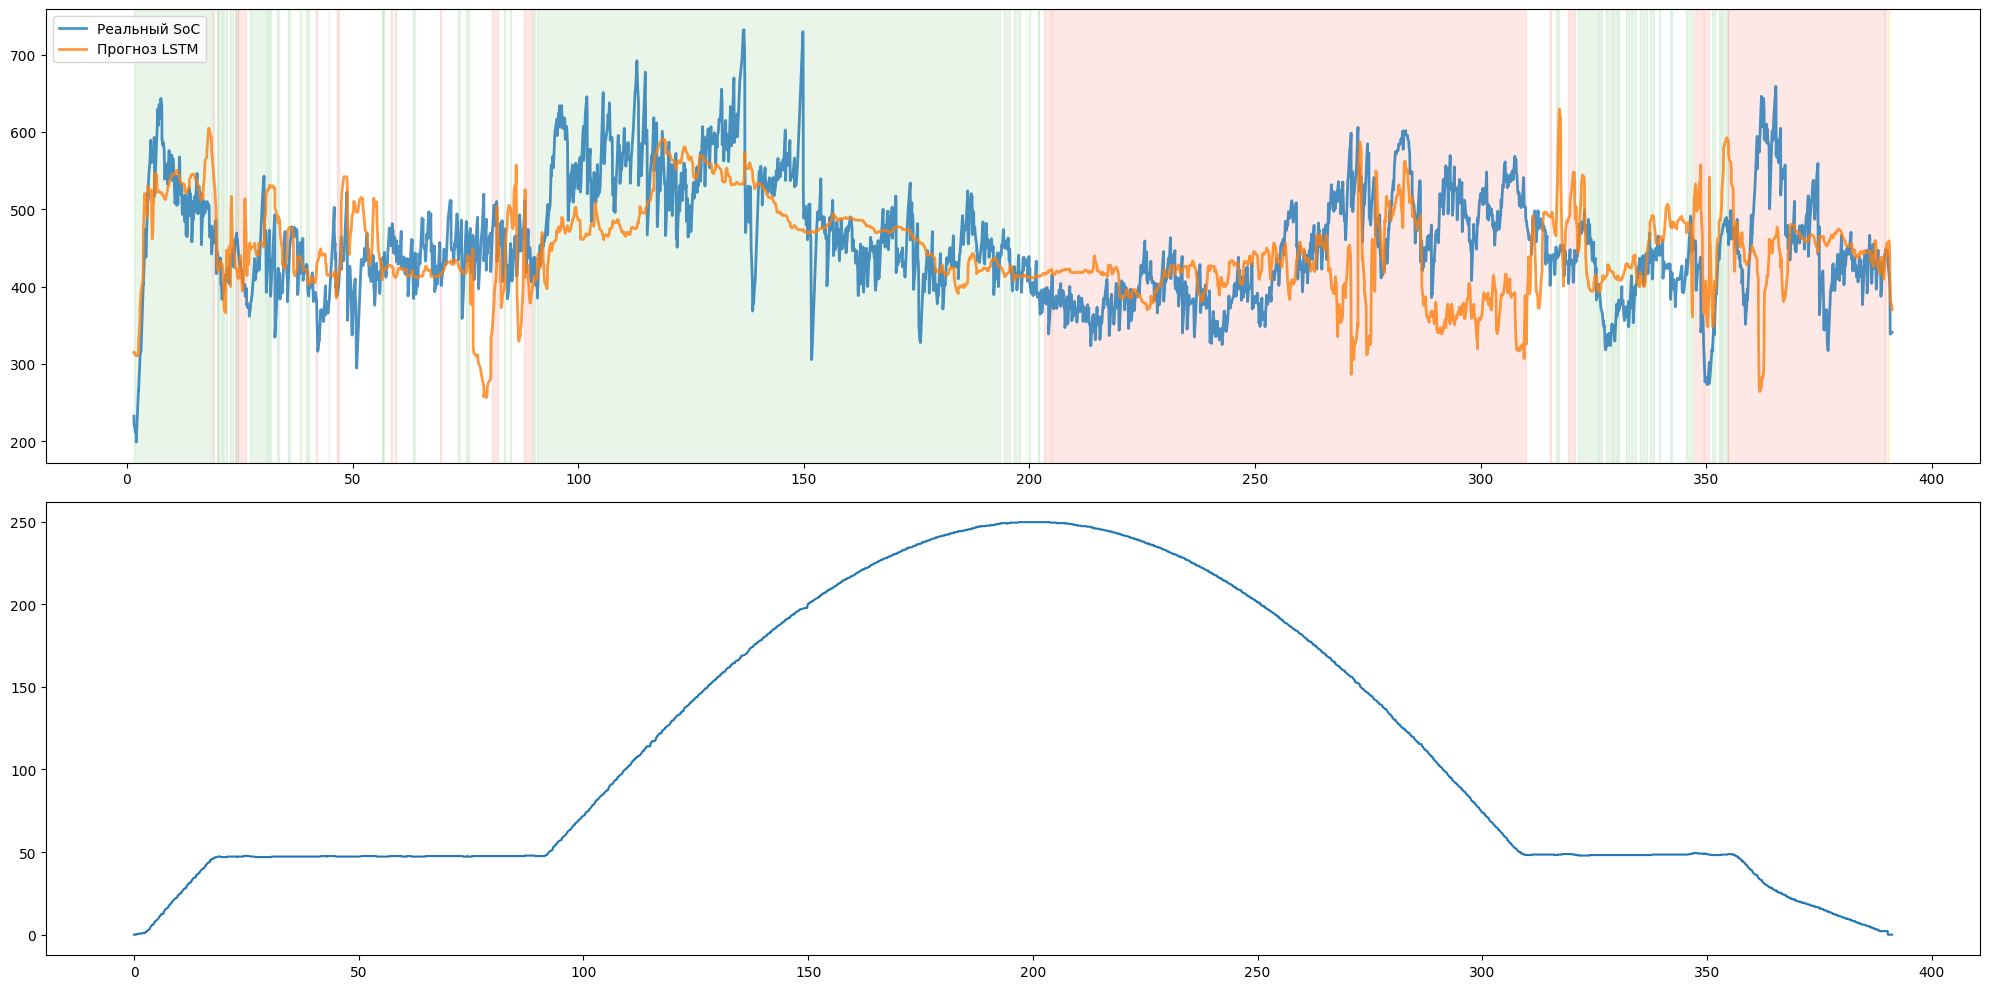

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

X_test_df = test_df[test_df['file_id'] == 391][FEATURES].copy()
y_test_df = test_df[test_df['file_id'] == 391]['soc_rate_smooth'].values

EPS = 0.2
X_test_df['speed_horizontal'] = np.sqrt(
    X_test_df['velocityX(mph)']**2 + X_test_df['velocityY(mph)']**2
)
conditions = [
    X_test_df['velocityZ(mph)'] * -1 > EPS,
    X_test_df['velocityZ(mph)'] * -1 < -EPS,
    (X_test_df['speed_horizontal'] < EPS) &
    (X_test_df['altitude_m'] < 1)
]

choices = [
    'climb',
    'descent',
    'motorsOn'
]

X_test_df['phase'] = np.select(
    conditions,
    choices,
    default='cruise'
)

X_file_scaled = scaler_X.transform(X_test_df[FEATURES])
y_file_scaled = scaler_y.transform(
    y_test_df.reshape(-1, 1)
).flatten()

X_seq, y_seq = create_sequences(
    X_file_scaled,
    y_file_scaled,
    WINDOW_SIZE
)

y_pred_scaled = model.predict(
    X_seq,
    verbose=0
).flatten()

y_true = scaler_y.inverse_transform(
    y_seq.reshape(-1, 1)
).flatten()

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

time_axis = (
    X_test_df['flight_time_s']
    .iloc[WINDOW_SIZE:WINDOW_SIZE + len(y_true)]
    .reset_index(drop=True)
)
axes[0].plot(
    time_axis,
    y_true,
    label='Реальный SoC',
    linewidth=2,
    alpha=0.8
)

axes[0].plot(
    time_axis,
    y_pred,
    label='Прогноз LSTM',
    linewidth=2,
    alpha=0.8
)

axes[1].plot(
    X_test_df['flight_time_s'].to_numpy(),
    X_test_df['altitude_m'].to_numpy()
)


phase_series = X_test_df['phase'].iloc[WINDOW_SIZE:].reset_index(drop=True)

n = min(len(phase_series), len(y_true))

phase_series = phase_series.iloc[:n]
x_axis = np.arange(n)

colors = {
    'climb': '#4CAF50',     # зелёный
    'descent': '#F44336',   # красный
    'cruise': '#FFFFFF',    # синий
    'motorsOn': '#FF9800'   # оранжевый
}

start_time = time_axis.iloc[0]
current_phase = phase_series.iloc[0]
start = 0

for i in range(1, n):
    if phase_series.iloc[i] != current_phase:

        axes[0].axvspan(
            time_axis.iloc[start],
            time_axis.iloc[i],
            color=colors.get(current_phase, 'gray'),
            alpha=0.12
        )

        start = i
        current_phase = phase_series.iloc[i]

axes[0].axvspan(
    time_axis.iloc[start],
    time_axis.iloc[n - 1],
    color=colors.get(current_phase, 'gray'),
    alpha=0.12
)
axes[0].legend()

# axes[idx].set_xlabel('Временной шаг')
# axes[idx].set_ylabel('SoC rate')
# axes[idx].set_title(f'Дата {test_df['datetime(utc)'].iloc[0]}')
# axes[idx].legend()
# axes[idx].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Text(0.5, 0, 'Долгота')

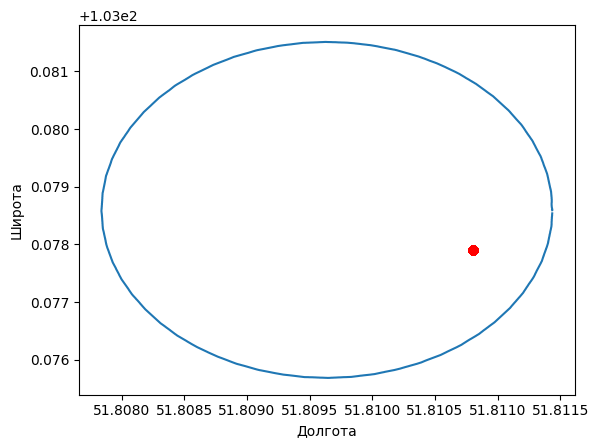

In [ ]:
df__ = test_df[test_df['file_id'] == 390]
plt.plot(df__['latitude'], df__['longitude'])
plt.scatter(df__['home_latitude'], df__['home_longitude'], c='red')
plt.ylabel('Широта')
plt.xlabel('Долгота')

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df__['flight_time_s'], df__['altitude_m'])
plt.title('Высота маршрута')
plt.ylabel('м')
plt.xlabel('Секунды')

NameError: name 'df__' is not defined

<Figure size 1500x500 with 0 Axes>

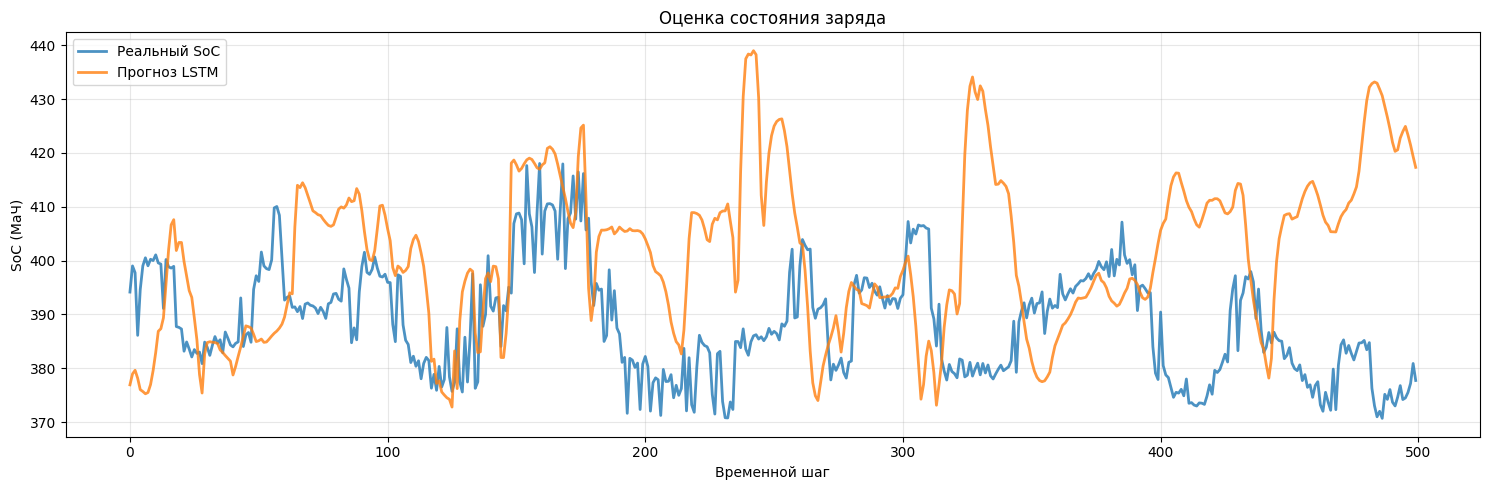

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(y_true[100000:100500], label='Реальный SoC', linewidth=2, alpha=0.8)
plt.plot(y_pred[100000:100500], label='Прогноз LSTM', linewidth=2, alpha=0.8)
plt.xlabel('Временной шаг')
plt.ylabel('SoC (МаЧ)')
plt.title('Оценка состояния заряда')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

In [ ]:
def estimate_remaining_flight(soc_current, soc_pred_trajectory,
                             current_A_avg, capacity_Ah=5.2,
                             safety_margin=0.2):
    soc_forecast = np.percentile(soc_pred_trajectory, 25)
    usable_soc = max(0, soc_current/100 - safety_margin)

    if current_A_avg < 0.01:
        return 999
    remaining_minutes = (usable_soc * capacity_Ah) / (current_A_avg / 60)
    return remaining_minutes

In [ ]:
print(model.predict(X_train))
print(y_train)

29278/29278 ━━━━━━━━━━━━━━━━━━━━ 98s 3ms/step
[[-0.03911325]
 [-0.04790048]
 [-0.05909156]
 ...
 [-0.00208918]
 [-0.00173767]
 [-0.00183868]]
[-0.12439159 -0.10955462 -0.10991201 ... -0.07277818 -0.07894742
 -0.08446176]


In [ ]:
model.evaluate(X_test, y_test)

7320/7320 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 0.0273 - mae: 0.0629 - mse: 4.9662 - rmse: 2.2285


[0.02731475606560707,
 0.06289465725421906,
 4.966205596923828,
 2.2284984588623047]

In [ ]:
EPS = 0.6

conditions = [
    X_test_df['velZ_ms'] * -1 > EPS,
    X_test_df['velZ_ms'] * -1 < -EPS,
    (X_test_df['speed_horizontal'] < EPS) & (X_test_df['altitude_m'] < 1)
]

choices = ['climb', 'descent', 'motorsOn']

X_test_df['phase'] = np.select(
    conditions,
    choices,
    default='cruise'
)
X_test_df['phase']

In [ ]:
colors = {
    'climb': 'green',
    'cruise': 'blue',
    'descent': 'red',
    'motorsOn': 'yellow'
}

plt.figure(figsize=(15, 5))

for phase, group in X_test_df.groupby('phase'):
    plt.scatter(
        group.index,
        group['altitude_m'],
        c=colors[phase],
        s=3,
        label=phase
    )

plt.legend()
plt.xlabel('Index')
plt.ylabel('Altitude')
plt.show()

In [ ]:
X_test_df

,satellites,phase_code,cell_imbalance_mV,altitude_m,pitch(deg),roll(deg),velocityX(mph),velocityY(mph),velocityZ(mph),flight_time_s,speed_horizontal,phase
1182349,10.0,1,19.0,0.0000,0.0,0.0,0.0,0.0,-1.12,0.000,0.0,climb
1182350,10.0,1,19.0,0.3048,0.0,0.0,0.0,0.0,-1.12,0.103,0.0,climb
1182351,10.0,1,19.0,0.3048,0.0,0.0,0.0,0.0,-1.12,0.105,0.0,climb
1182352,10.0,1,19.0,0.3048,0.0,0.0,0.0,0.0,-1.12,0.109,0.0,climb
1182353,10.0,1,17.0,0.3048,0.0,0.0,0.0,0.0,-1.12,0.216,0.0,climb
...,...,...,...,...,...,...,...,...,...,...,...,...
1183589,10.0,1,19.0,0.0000,0.0,0.0,0.0,0.0,0.00,134.852,0.0,motorsOn
1183590,10.0,1,19.0,0.0000,0.0,0.0,0.0,0.0,0.00,134.952,0.0,motorsOn
1183591,10.0,1,19.0,0.0000,0.0,0.0,0.0,0.0,0.00,135.054,0.0,motorsOn
1183592,10.0,1,19.0,0.0000,0.0,0.0,0.0,0.0,0.00,135.158,0.0,motorsOn


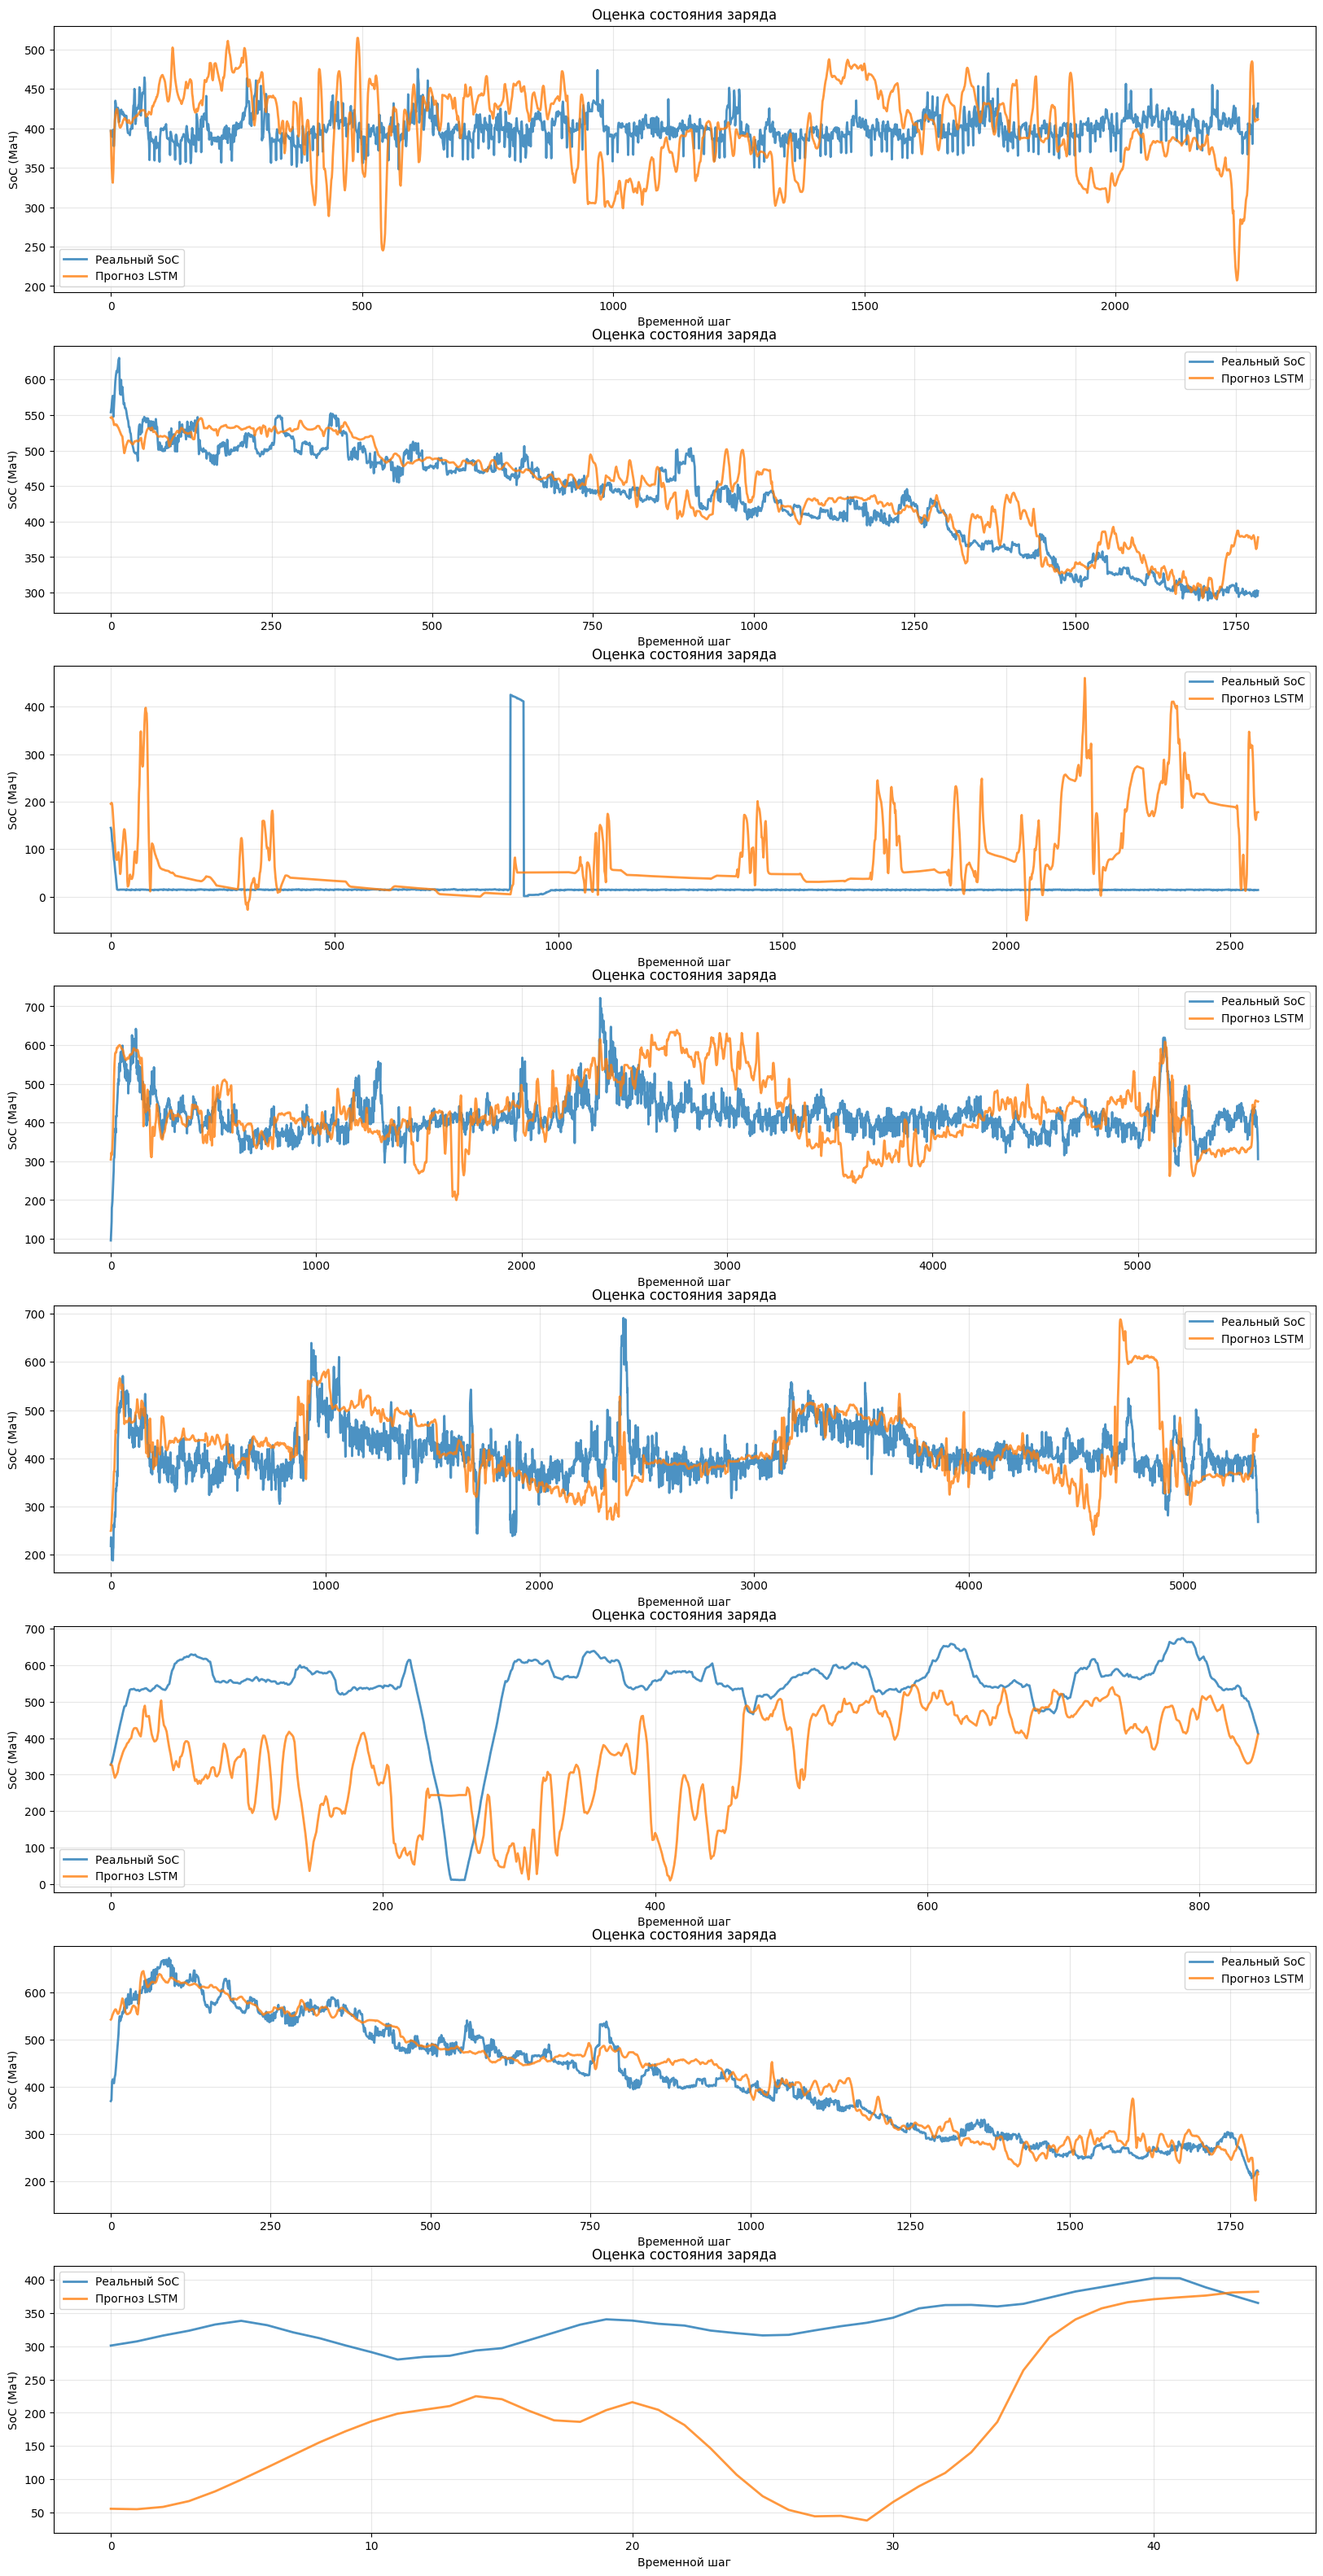

In [ ]:
charts = test_df['file_id'].unique()
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
# fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

for idx, file_id in enumerate(test_df['file_id'].unique()):
    X_test_df = test_df[test_df['file_id'] == file_id][FEATURES].values
    y_test_df = test_df[test_df['file_id'] == file_id]['soc_rate_smooth'].values

    EPS = 0.6

    conditions = [
        X_test_df['velZ_ms'] * -1 > EPS,
        X_test_df['velZ_ms'] * -1 < -EPS,
        (X_test_df['speed_horizontal'] < EPS) & (X_test_df['altitude_m'] < 1)
    ]

    choices = ['climb', 'descent', 'motorsOn']

    X_test_df['phase'] = np.select(
        conditions,
        choices,
        default='cruise'
    )
    X_test_df['phase']

    X_file_scaled = scaler_X.transform(X_test_df)
    y_file_scaled = scaler_y.transform(y_test_df.reshape(-1, 1)).flatten()

    X_seq, y_seq = create_sequences(X_file_scaled, y_file_scaled, WINDOW_SIZE)

    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()

    y_true = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    axes[idx].plot(y_true, label='Реальный SoC', linewidth=2, alpha=0.8)
    # axes[idx].plot(y_test_df['soc_rate_smooth'].values)
    axes[idx].plot(y_pred, label='Прогноз LSTM', linewidth=2, alpha=0.8)
    axes[idx].set_xlabel('Временной шаг')
    axes[idx].set_ylabel('SoC (МаЧ)')
    axes[idx].set_title('Оценка состояния заряда')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Модификация с Attention

In [ ]:
inp = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = layers.LSTM(50, return_sequences=True,
                kernel_initializer='he_normal')(inp)
x = layers.LSTM(50, return_sequences=True,
                kernel_initializer='he_normal')(x)
x = layers.LSTM(50, return_sequences=True,
                kernel_initializer='he_normal')(x)
attention = layers.Attention()([x, x])

x = layers.Add()([x, attention])
x = layers.LayerNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(50, activation='relu',
                  kernel_initializer='he_normal')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1, activation='linear')(x)
model = tf.keras.Model(inputs=inp, outputs=out, name='soc_lstm_attention')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "soc_lstm_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 15, 50)    │     12,200 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 15, 50)    │     20,200 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 15, 50)    │     20,200 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 15, 50)    │          0 │ lstm_2[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 50)    │          0 │ lstm_2[0][0],     │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 50)    │        100 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 50)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │      2,550 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,301 (216.02 KB)

 Trainable params: 55,301 (216.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history_lstm_attention = model.fit(
    X_train, y_train,
    batch_size=512,
    epochs=100,
    validation_split=0.15,
    callbacks=[cb, reduce_lr],
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Метрики
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
max_err = np.max(np.abs(y_true - y_pred))
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f"\nРезультаты на тесте:")
print(f"   MAE: {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Max Error: {max_err:.2f}")
print(f"   R2: {r2:.4f}")


Epoch 1/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 0.0152 - mae: 0.0634 - mse: 1.4760 - rmse: 1.2149 - val_loss: 0.0014 - val_mae: 0.0329 - val_mse: 0.0028 - val_rmse: 0.0529 - learning_rate: 0.0010
Epoch 2/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0092 - mae: 0.0413 - mse: 1.4627 - rmse: 1.2094 - val_loss: 0.0013 - val_mae: 0.0316 - val_mse: 0.0026 - val_rmse: 0.0511 - learning_rate: 0.0010
Epoch 3/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0090 - mae: 0.0393 - mse: 1.4624 - rmse: 1.2093 - val_loss: 0.0012 - val_mae: 0.0304 - val_mse: 0.0024 - val_rmse: 0.0487 - learning_rate: 0.0010
Epoch 4/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.0089 - mae: 0.0377 - mse: 1.4621 - rmse: 1.2092 - val_loss: 0.0012 - val_mae: 0.0291 - val_mse: 0.0023 - val_rmse: 0.0482 - learning_rate: 0.0010
Epoch 5/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0088 - mae: 0.0363 - mse: 1.4619 - rmse: 1.2091 - val_loss: 0.0011 - val_mae: 0.0

In [ ]:
model.evaluate(X_test, y_test)

7213/7213 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 0.0018 - mae: 0.0356 - mse: 0.0036 - rmse: 0.0596


[0.0017667404608801007,
 0.03557179123163223,
 0.00355057162232697,
 0.059586673974990845]

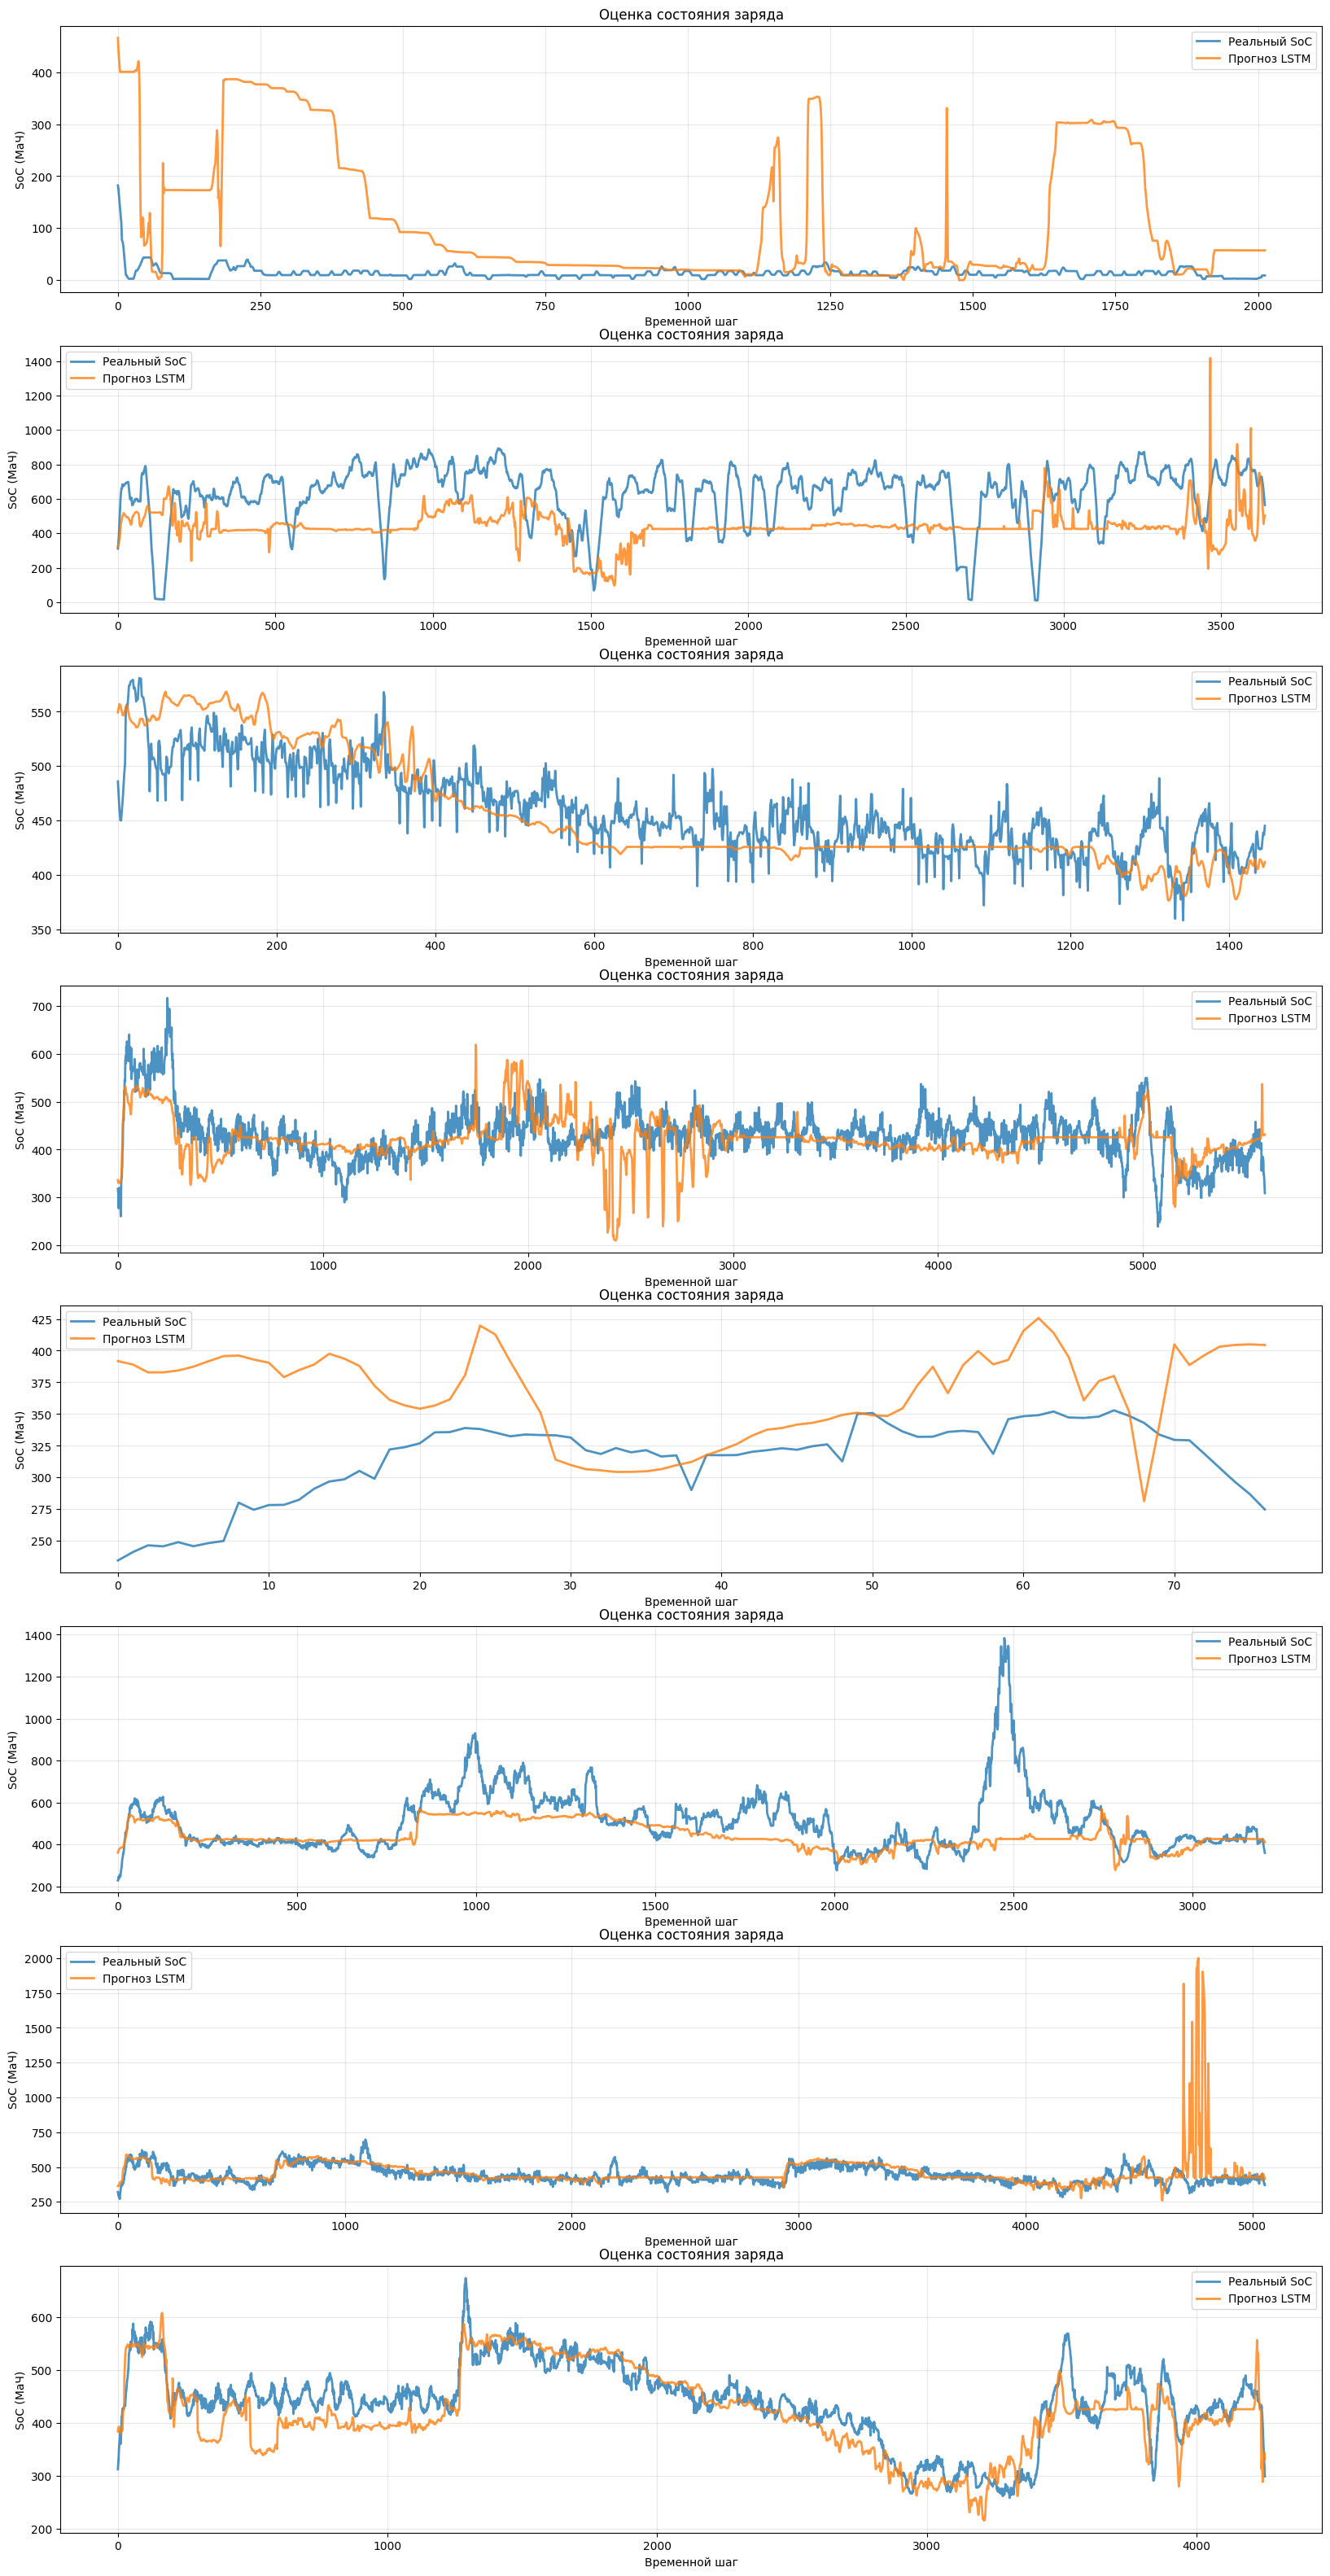

In [ ]:
charts = test_df['file_id'].unique()
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
# fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

for idx, file_id in enumerate(test_df['file_id'].unique()):
    X_test_df = test_df[test_df['file_id'] == file_id][FEATURES].values
    y_test_df = test_df[test_df['file_id'] == file_id]['soc_rate_smooth'].values

    X_file_scaled = scaler_X.transform(X_test_df)
    y_file_scaled = scaler_y.transform(y_test_df.reshape(-1, 1)).flatten()

    X_seq, y_seq = create_sequences(X_file_scaled, y_file_scaled, WINDOW_SIZE)

    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()

    y_true = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    axes[idx].plot(y_true, label='Реальный SoC', linewidth=2, alpha=0.8)
    # axes[idx].plot(y_test_df['soc_rate_smooth'].values)
    axes[idx].plot(y_pred, label='Прогноз LSTM', linewidth=2, alpha=0.8)
    axes[idx].set_xlabel('Временной шаг')
    axes[idx].set_ylabel('SoC (МаЧ)')
    axes[idx].set_title('Оценка состояния заряда')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

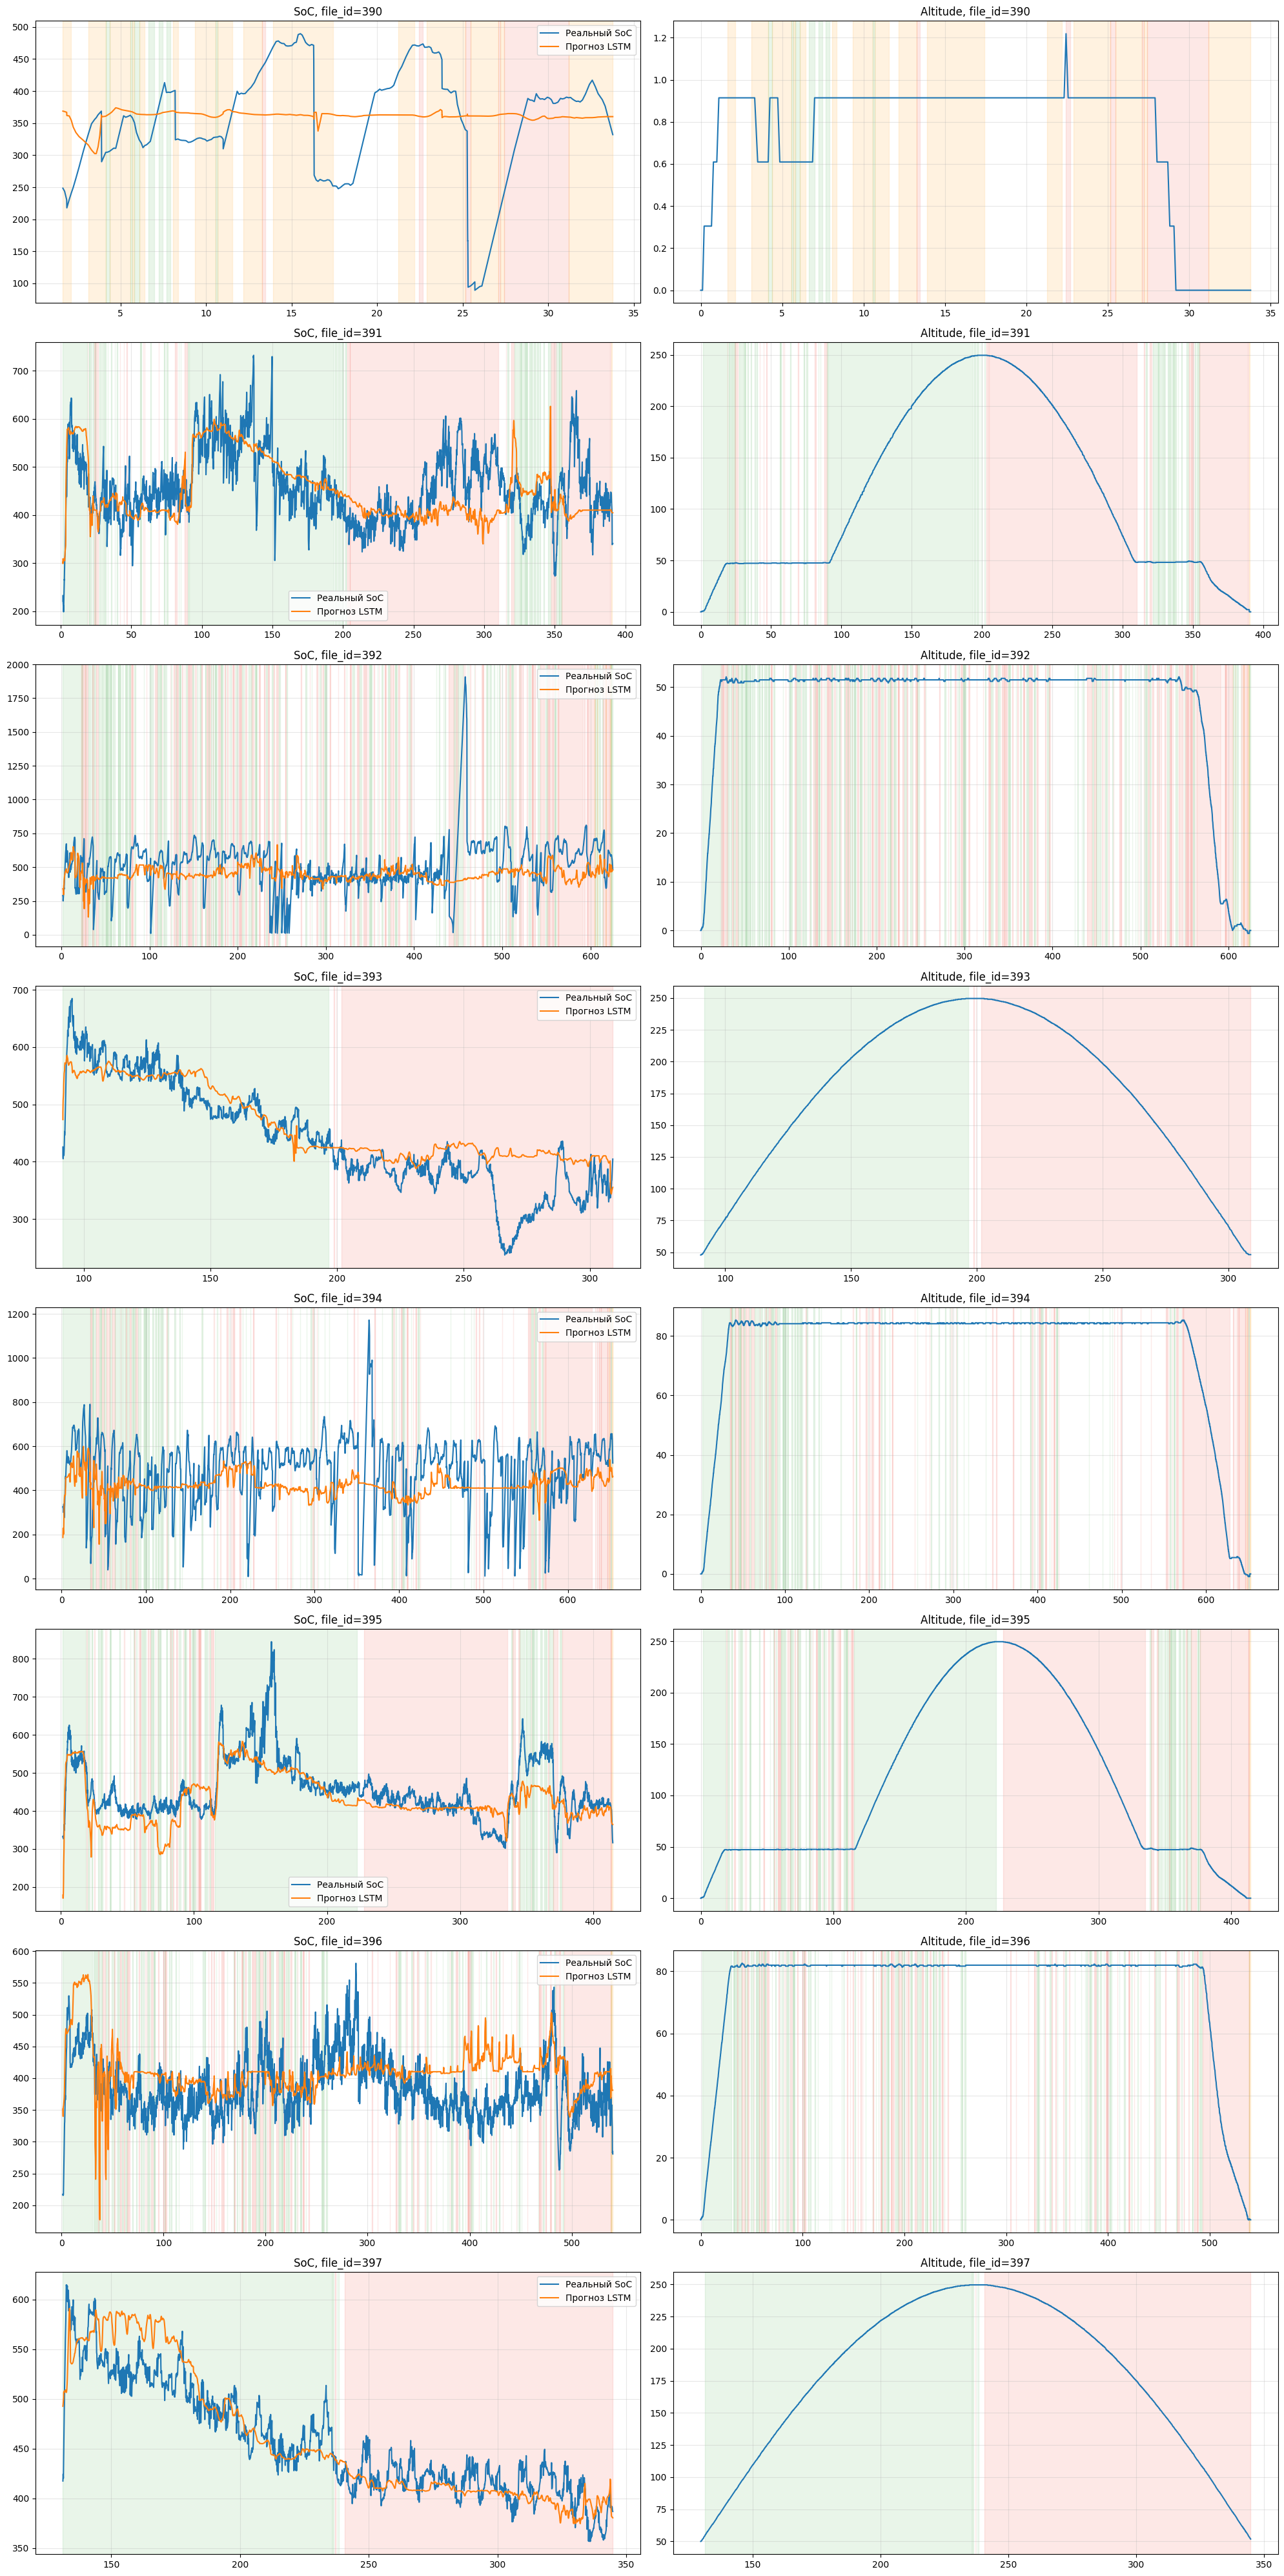

In [ ]:
charts = test_df['file_id'].unique()

fig, axes = plt.subplots(
    len(charts),
    2,
    figsize=(20, 5 * len(charts))
)

if len(charts) == 1:
    axes = np.array([axes])

colors = {
    'climb': '#4CAF50',
    'descent': '#F44336',
    'cruise': '#FFFFFF',
    'motorsOn': '#FF9800'
}

for idx, file_id in enumerate(charts):

    X_test_df = test_df[
        test_df['file_id'] == file_id
    ][FEATURES].copy()

    y_test_df = test_df[
        test_df['file_id'] == file_id
    ]['soc_rate_smooth'].values

    EPS = 0.2

    X_test_df['speed_horizontal'] = np.sqrt(
        X_test_df['velocityX(mph)']**2 +
        X_test_df['velocityY(mph)']**2
    )

    conditions = [
        X_test_df['velocityZ(mph)'] * -1 > EPS,
        X_test_df['velocityZ(mph)'] * -1 < -EPS,
        (
            (X_test_df['speed_horizontal'] < EPS) &
            (X_test_df['altitude_m'] < 1)
        )
    ]

    choices = [
        'climb',
        'descent',
        'motorsOn'
    ]

    X_test_df['phase'] = np.select(
        conditions,
        choices,
        default='cruise'
    )

    X_scaled = scaler_X.transform(
        X_test_df[FEATURES]
    )

    y_scaled = scaler_y.transform(
        y_test_df.reshape(-1, 1)
    ).flatten()

    X_seq, y_seq = create_sequences(
        X_scaled,
        y_scaled,
        WINDOW_SIZE
    )

    y_pred_scaled = model.predict(
        X_seq,
        verbose=0
    ).flatten()

    y_true = scaler_y.inverse_transform(
        y_seq.reshape(-1, 1)
    ).flatten()

    y_pred = scaler_y.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).flatten()

    time_axis = (
        X_test_df['flight_time_s']
        .iloc[WINDOW_SIZE:WINDOW_SIZE + len(y_true)]
        .reset_index(drop=True)
    )
    axes[idx, 0].plot(
        time_axis,
        y_true,
        label='Реальный SoC'
    )

    axes[idx, 0].plot(
        time_axis,
        y_pred,
        label='Прогноз LSTM'
    )

    axes[idx, 1].plot(
        X_test_df['flight_time_s'],
        X_test_df['altitude_m']
    )

    phase_series = (
        X_test_df['phase']
        .iloc[WINDOW_SIZE:]
        .reset_index(drop=True)
    )

    n = min(
        len(phase_series),
        len(time_axis)
    )

    phase_series = phase_series.iloc[:n]

    start = 0
    current_phase = phase_series.iloc[0]

    for i in range(1, n):
        if phase_series.iloc[i] != current_phase:

            start_time = time_axis.iloc[start]
            end_time = time_axis.iloc[i]

            for ax in [axes[idx, 0], axes[idx, 1]]:
                ax.axvspan(
                    start_time,
                    end_time,
                    color=colors[current_phase],
                    alpha=0.12
                )

            current_phase = phase_series.iloc[i]
            start = i

    for ax in [axes[idx, 0], axes[idx, 1]]:
        ax.axvspan(
            time_axis.iloc[start],
            time_axis.iloc[n - 1],
            color=colors[current_phase],
            alpha=0.12
        )

    axes[idx, 0].set_title(
        f"SoC, file_id={file_id}"
    )

    axes[idx, 1].set_title(
        f"Altitude, file_id={file_id}"
    )

    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


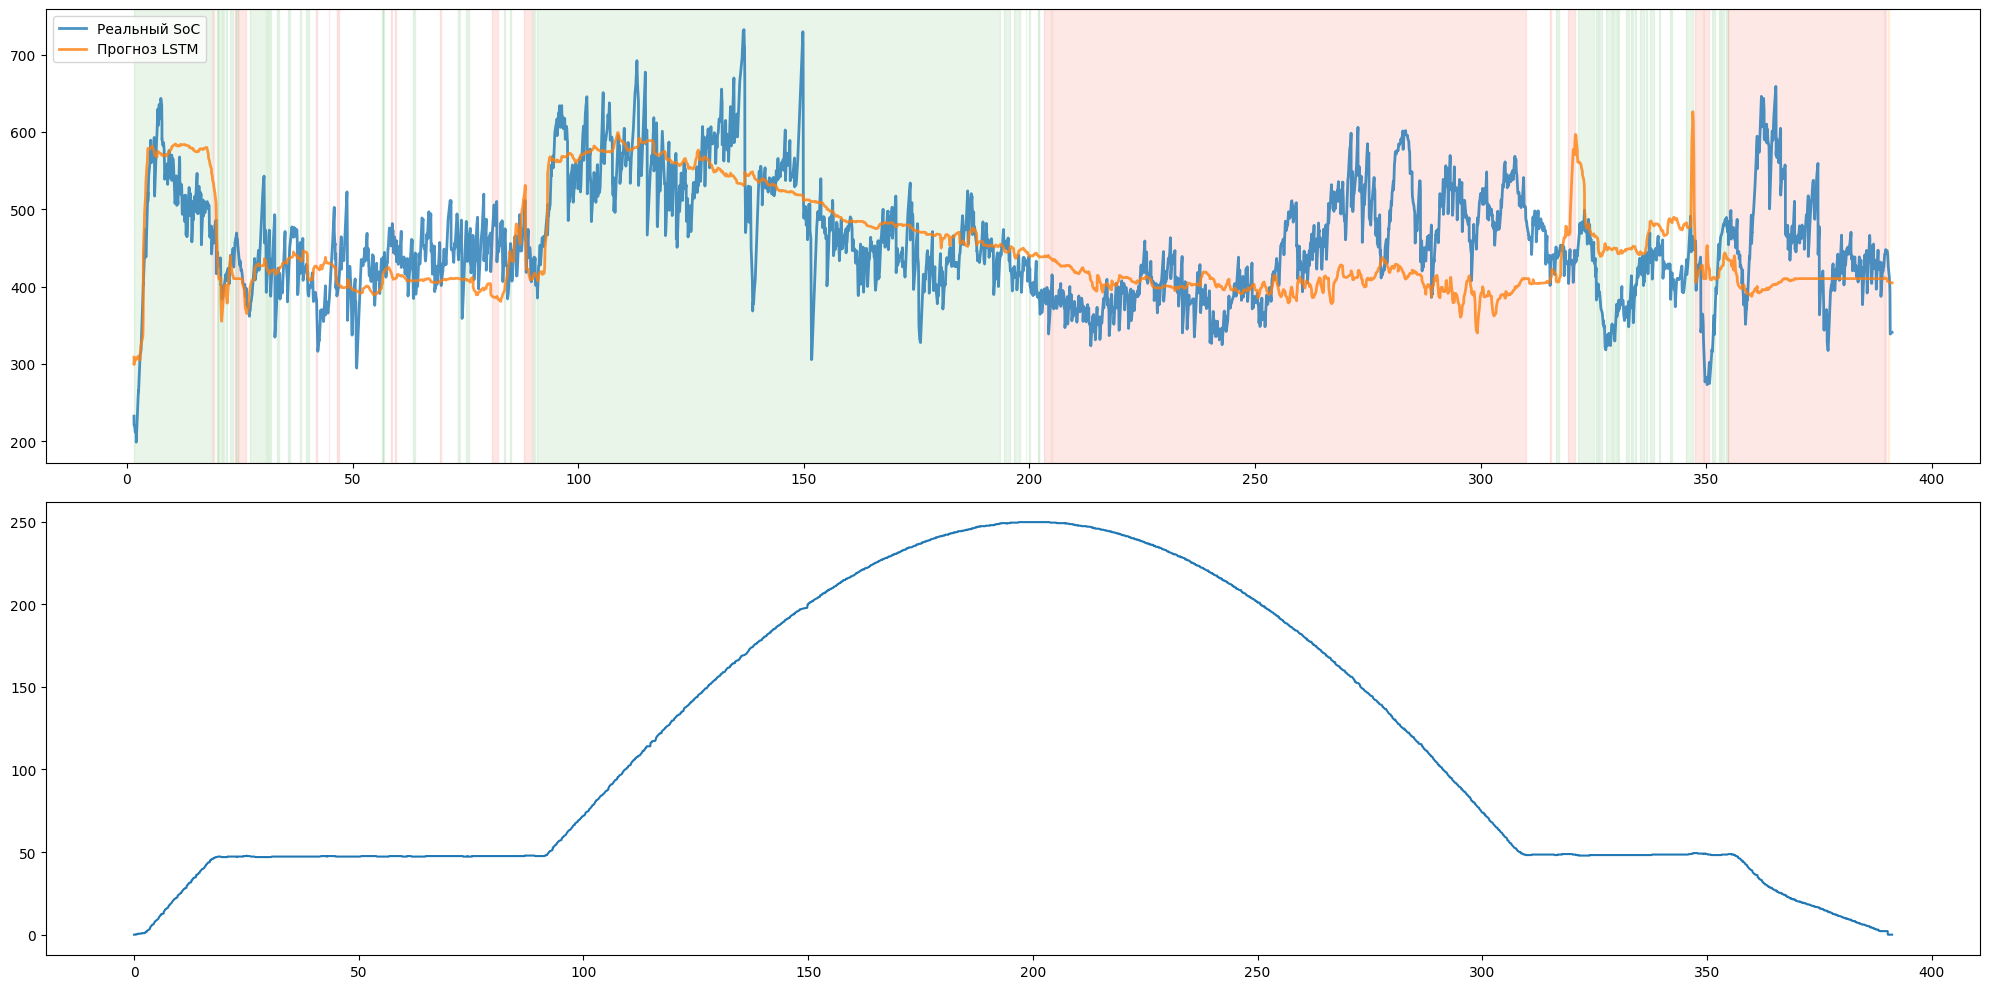

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

X_test_df = test_df[test_df['file_id'] == 391][FEATURES].copy()
y_test_df = test_df[test_df['file_id'] == 391]['soc_rate_smooth'].values

EPS = 0.2
X_test_df['speed_horizontal'] = np.sqrt(
    X_test_df['velocityX(mph)']**2 + X_test_df['velocityY(mph)']**2
)
conditions = [
    X_test_df['velocityZ(mph)'] * -1 > EPS, # набор высоты
    X_test_df['velocityZ(mph)'] * -1 < -EPS, # снижение
    (X_test_df['speed_horizontal'] < EPS) &
    (X_test_df['altitude_m'] < 1)
]

choices = [
    'climb',
    'descent',
    'motorsOn'
]

X_test_df['phase'] = np.select(
    conditions,
    choices,
    default='cruise'
)

X_file_scaled = scaler_X.transform(X_test_df[FEATURES])
y_file_scaled = scaler_y.transform(
    y_test_df.reshape(-1, 1)
).flatten()

X_seq, y_seq = create_sequences(
    X_file_scaled,
    y_file_scaled,
    WINDOW_SIZE
)

y_pred_scaled = model.predict(
    X_seq,
    verbose=0
).flatten()

y_true = scaler_y.inverse_transform(
    y_seq.reshape(-1, 1)
).flatten()

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

time_axis = (
    X_test_df['flight_time_s']
    .iloc[WINDOW_SIZE:WINDOW_SIZE + len(y_true)]
    .reset_index(drop=True)
)
axes[0].plot(
    time_axis,
    y_true,
    label='Реальный SoC',
    linewidth=2,
    alpha=0.8
)

axes[0].plot(
    time_axis,
    y_pred,
    label='Прогноз LSTM',
    linewidth=2,
    alpha=0.8
)

axes[1].plot(
    X_test_df['flight_time_s'].to_numpy(),
    X_test_df['altitude_m'].to_numpy()
)

phase_series = X_test_df['phase'].iloc[WINDOW_SIZE:].reset_index(drop=True)

n = min(len(phase_series), len(y_true))

phase_series = phase_series.iloc[:n]
x_axis = np.arange(n)

colors = {
    'climb': '#4CAF50',     # зелёный
    'descent': '#F44336',   # красный
    'cruise': '#FFFFFF',    # синий
    'motorsOn': '#FF9800'   # оранжевый
}

start_time = time_axis.iloc[0]
current_phase = phase_series.iloc[0]
start = 0

for i in range(1, n):
    if phase_series.iloc[i] != current_phase:

        axes[0].axvspan(
            time_axis.iloc[start],
            time_axis.iloc[i],
            color=colors.get(current_phase, 'gray'),
            alpha=0.12
        )

        start = i
        current_phase = phase_series.iloc[i]

axes[0].axvspan(
    time_axis.iloc[start],
    time_axis.iloc[n - 1],
    color=colors.get(current_phase, 'gray'),
    alpha=0.12
)
axes[0].legend()

# axes[idx].set_xlabel('Временной шаг')
# axes[idx].set_ylabel('SoC rate')
# axes[idx].set_title(f'Дата {test_df['datetime(utc)'].iloc[0]}')
# axes[idx].legend()
# axes[idx].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Multi head attention

In [ ]:
inp = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = layers.Bidirectional(  # для лучшего контекста
    layers.LSTM(64, return_sequences=True)
)(inp)

attn = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(x, x)

x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

x = layers.GlobalAveragePooling1D()(x)
out = layers.Dense(1)(x)

model = tf.keras.Model(inputs=inp, outputs=out, name='soc_lstm_multihead_attention')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "soc_lstm_multihead_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 15, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 15, 128)   │     38,400 │ input_layer_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 128)   │     33,088 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 128)   │          0 │ bidirectional[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 15, 64)    │      8,256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 15, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_2[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 80,065 (312.75 KB)

 Trainable params: 80,065 (312.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history_multi_attention = model.fit(
    X_train, y_train,
    batch_size=512,
    epochs=100,
    validation_split=0.15,
    callbacks=[cb, reduce_lr],
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
max_err = np.max(np.abs(y_true - y_pred))
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f"\nРезультаты на тесте:")
print(f"   MAE: {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Max Error: {max_err:.2f}")
print(f"   R2: {r2:.4f}")


Epoch 1/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0105 - mae: 0.0512 - mse: 1.4645 - rmse: 1.2102 - val_loss: 0.0012 - val_mae: 0.0290 - val_mse: 0.0023 - val_rmse: 0.0483 - learning_rate: 0.0010
Epoch 2/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - loss: 0.0089 - mae: 0.0367 - mse: 1.4614 - rmse: 1.2089 - val_loss: 0.0012 - val_mae: 0.0287 - val_mse: 0.0023 - val_rmse: 0.0483 - learning_rate: 0.0010
Epoch 3/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0088 - mae: 0.0355 - mse: 1.4602 - rmse: 1.2084 - val_loss: 0.0011 - val_mae: 0.0273 - val_mse: 0.0022 - val_rmse: 0.0467 - learning_rate: 0.0010
Epoch 4/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0087 - mae: 0.0347 - mse: 1.4559 - rmse: 1.2066 - val_loss: 0.0011 - val_mae: 0.0277 - val_mse: 0.0022 - val_rmse: 0.0474 - learning_rate: 0.0010
Epoch 5/100
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - loss: 0.0087 - mae: 0.0343 - mse: 1.4512 - rmse: 1.2047 - val_loss: 0.0011 - val_mae: 0.0

In [ ]:
model.evaluate(X_test, y_test)

7213/7213 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - loss: 0.0017 - mae: 0.0339 - mse: 0.0034 - rmse: 0.0585


[0.0017058375524356961,
 0.03387750685214996,
 0.0034233583137392998,
 0.0585094690322876]

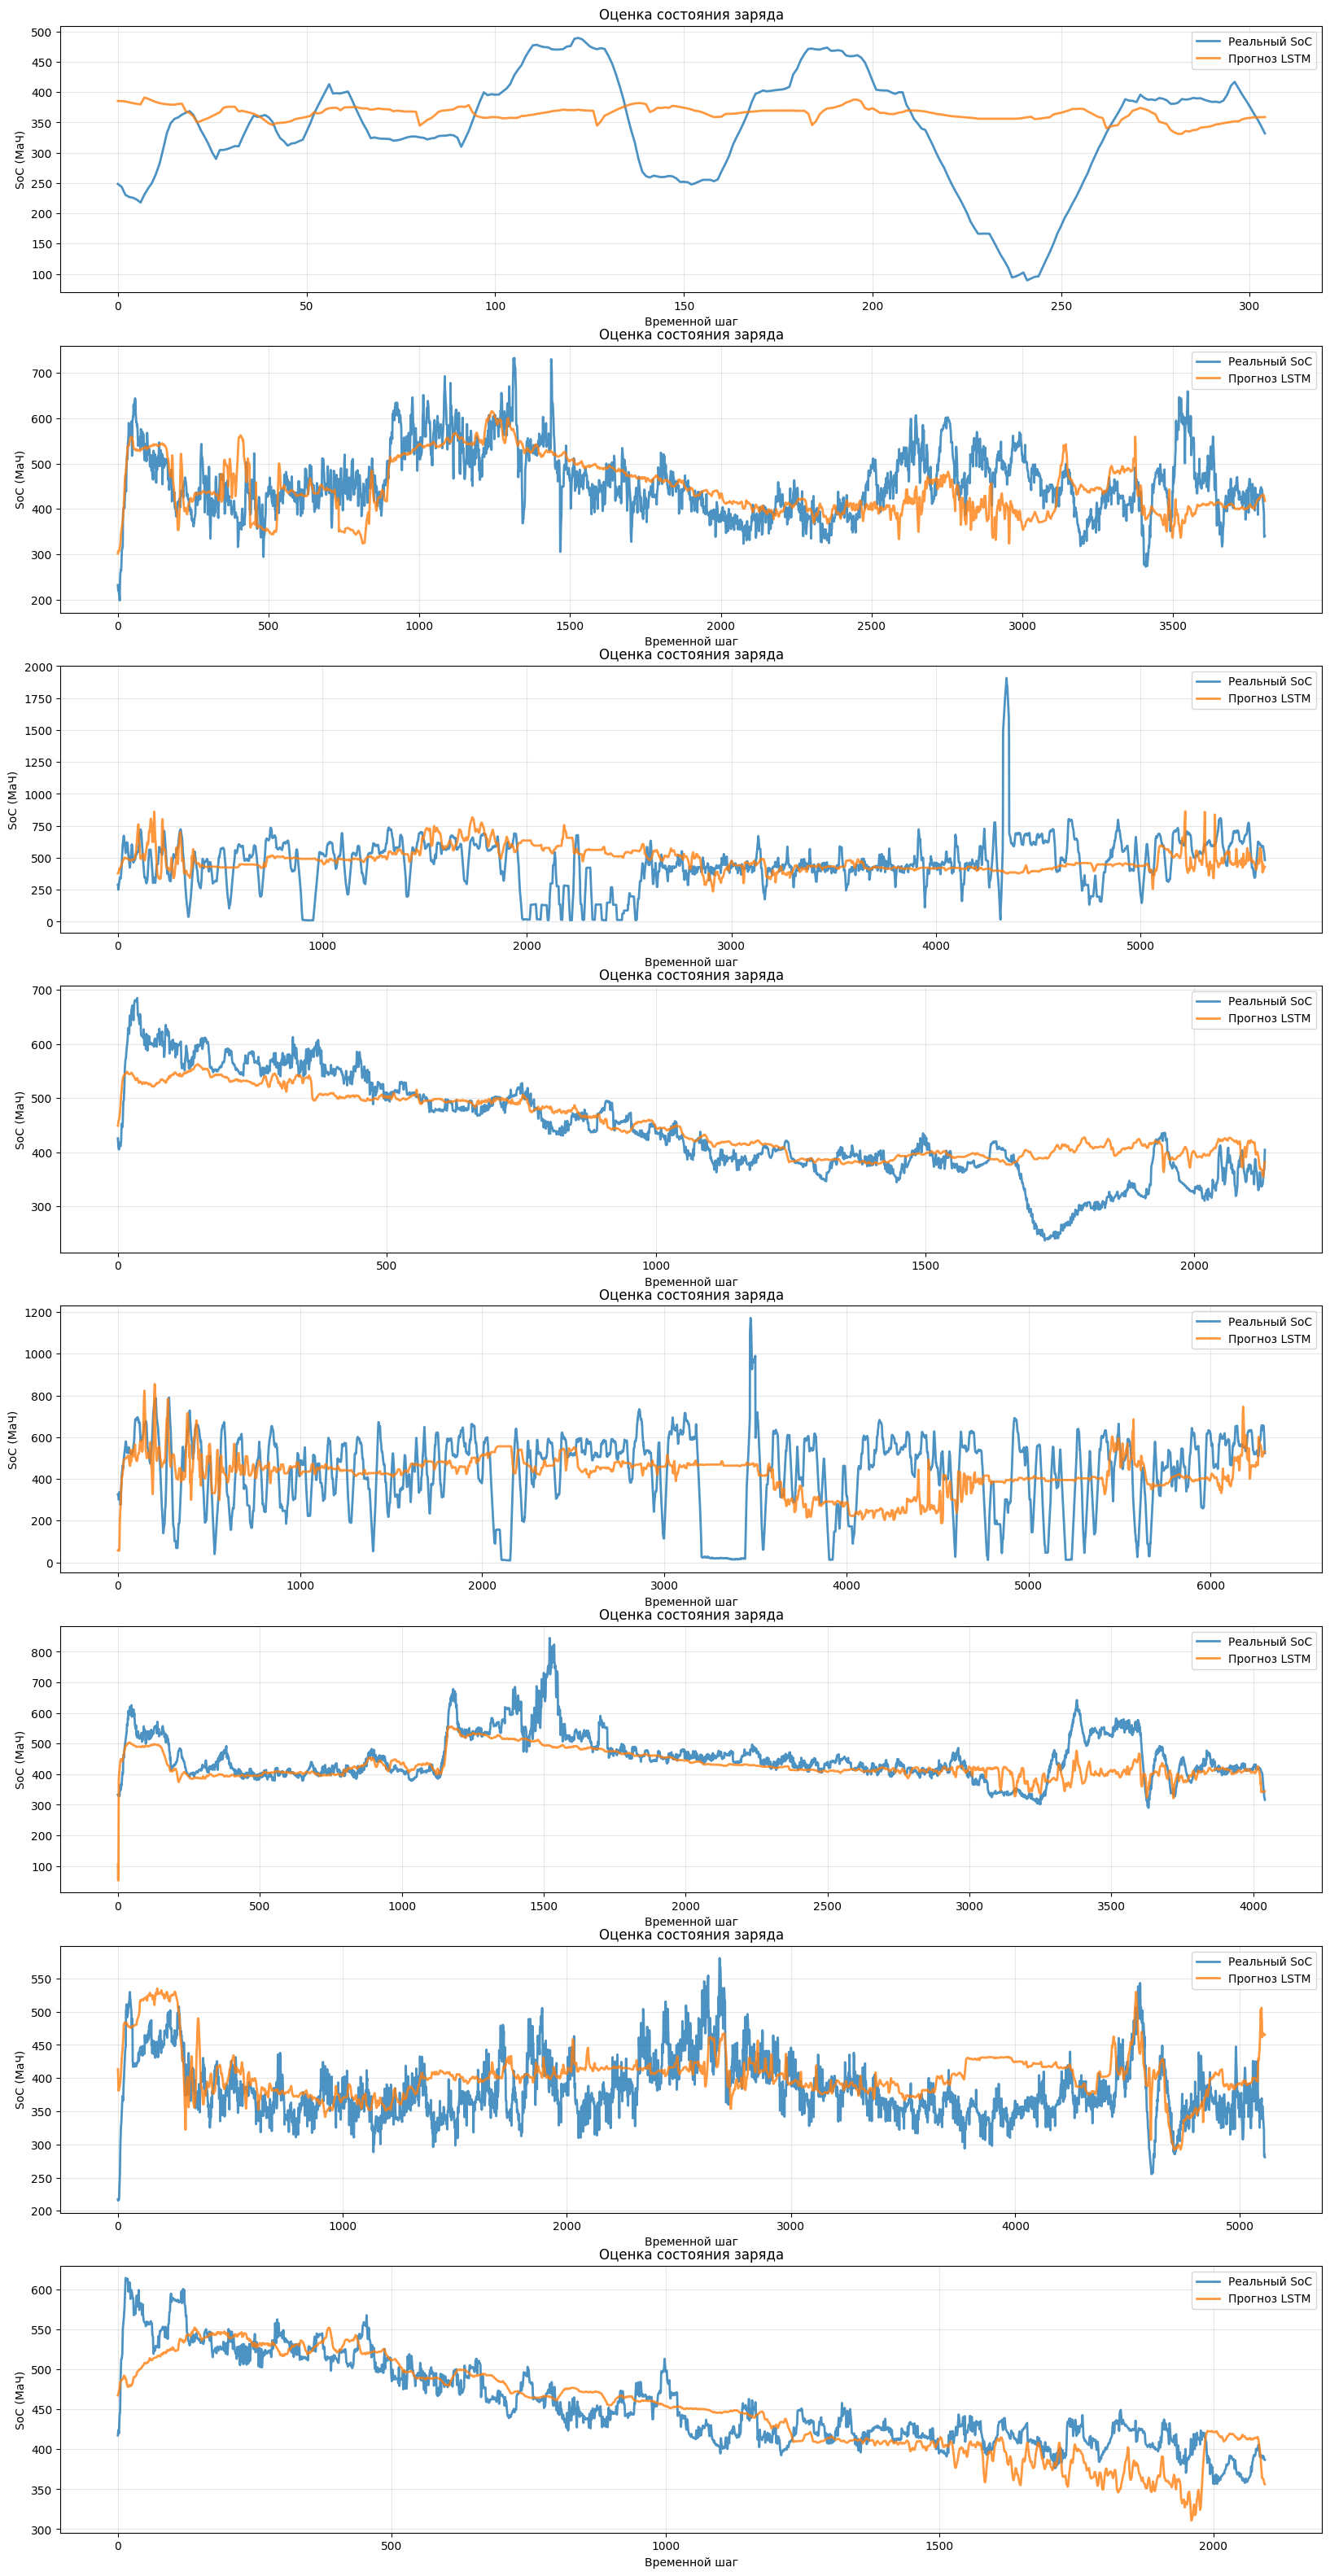

In [ ]:
charts = test_df['file_id'].unique()
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
# fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

for idx, file_id in enumerate(test_df['file_id'].unique()):
    X_test_df = test_df[test_df['file_id'] == file_id][FEATURES].values
    y_test_df = test_df[test_df['file_id'] == file_id]['soc_rate_smooth'].values

    X_file_scaled = scaler_X.transform(X_test_df)
    y_file_scaled = scaler_y.transform(y_test_df.reshape(-1, 1)).flatten()

    X_seq, y_seq = create_sequences(X_file_scaled, y_file_scaled, WINDOW_SIZE)

    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()

    y_true = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    axes[idx].plot(y_true, label='Реальный SoC', linewidth=2, alpha=0.8)
    # axes[idx].plot(y_test_df['soc_rate_smooth'].values)
    axes[idx].plot(y_pred, label='Прогноз LSTM', linewidth=2, alpha=0.8)
    axes[idx].set_xlabel('Временной шаг')
    axes[idx].set_ylabel('SoC (МаЧ)')
    axes[idx].set_title('Оценка состояния заряда')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


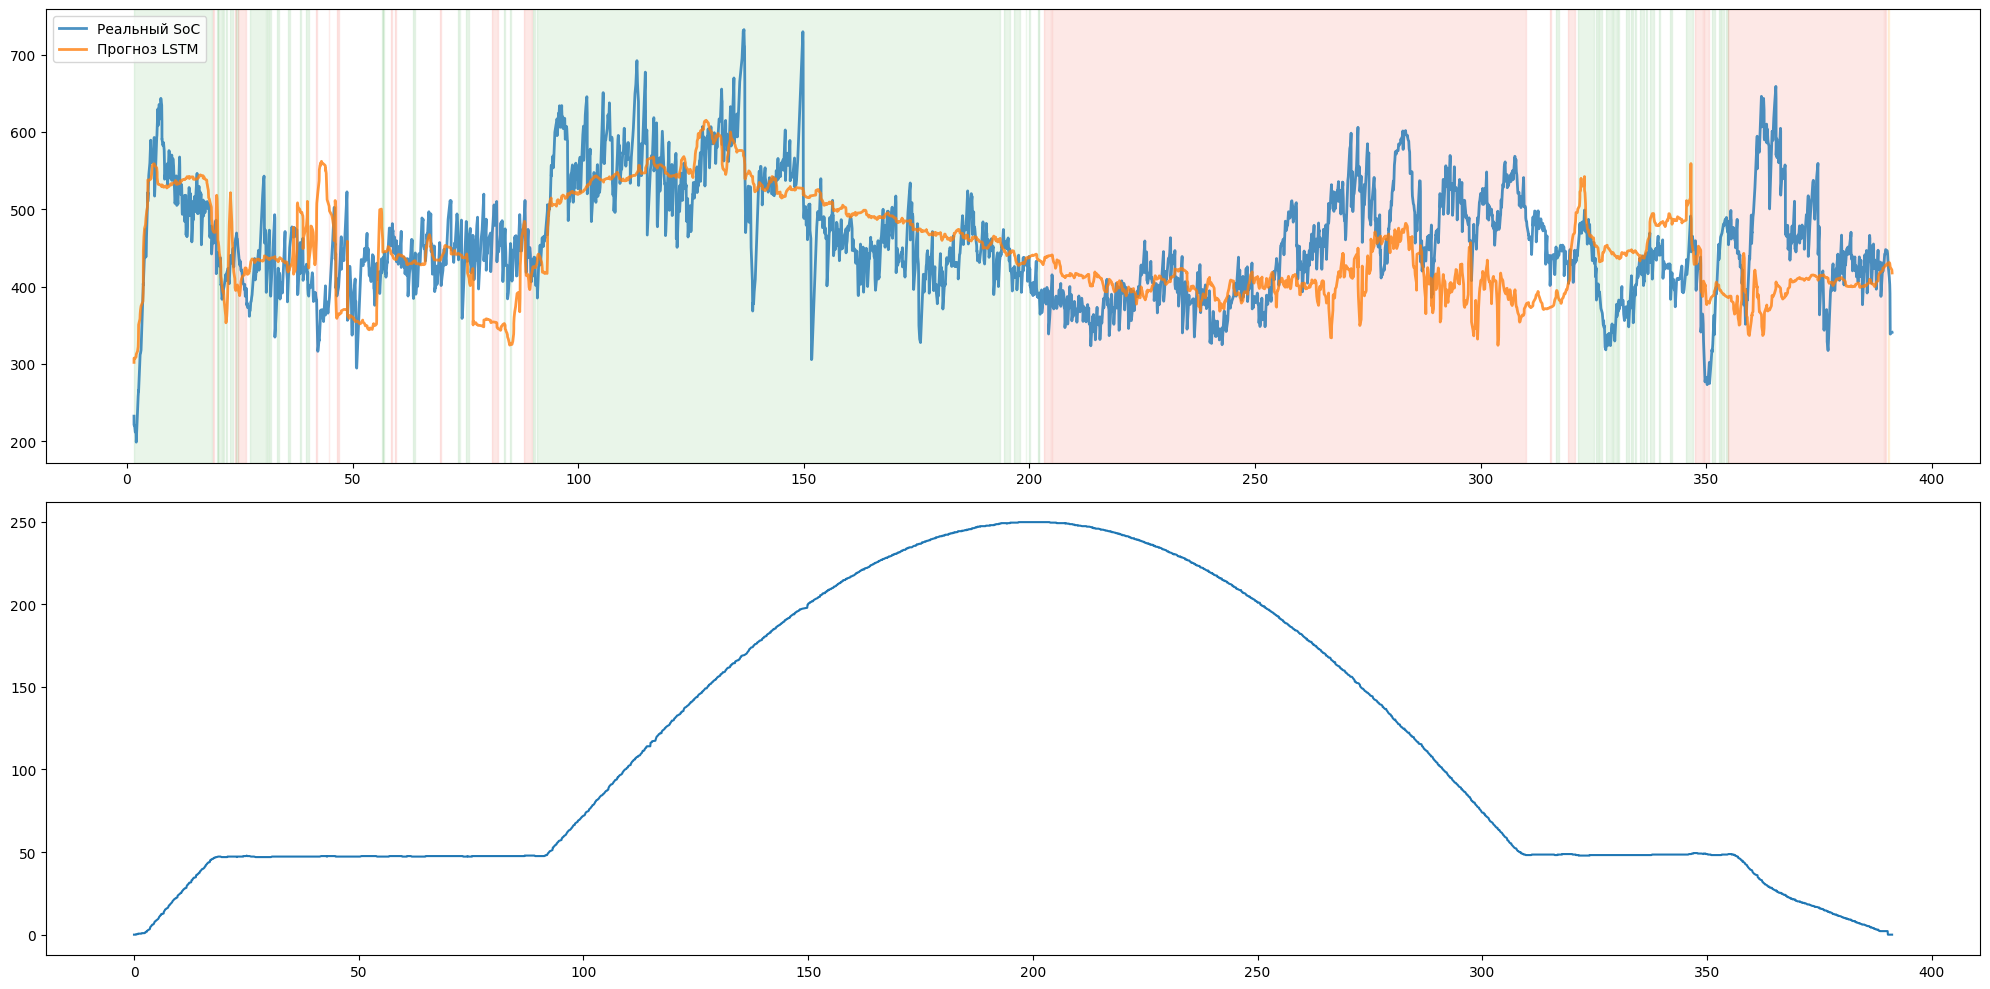

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

X_test_df = test_df[test_df['file_id'] == 391][FEATURES].copy()
y_test_df = test_df[test_df['file_id'] == 391]['soc_rate_smooth'].values

EPS = 0.2
X_test_df['speed_horizontal'] = np.sqrt(
    X_test_df['velocityX(mph)']**2 + X_test_df['velocityY(mph)']**2
)
conditions = [
    X_test_df['velocityZ(mph)'] * -1 > EPS,
    X_test_df['velocityZ(mph)'] * -1 < -EPS,
    (X_test_df['speed_horizontal'] < EPS) &
    (X_test_df['altitude_m'] < 1)
]

choices = [
    'climb',
    'descent',
    'motorsOn'
]

X_test_df['phase'] = np.select(
    conditions,
    choices,
    default='cruise'
)

X_file_scaled = scaler_X.transform(X_test_df[FEATURES])
y_file_scaled = scaler_y.transform(
    y_test_df.reshape(-1, 1)
).flatten()

X_seq, y_seq = create_sequences(
    X_file_scaled,
    y_file_scaled,
    WINDOW_SIZE
)

y_pred_scaled = model.predict(
    X_seq,
    verbose=0
).flatten()

y_true = scaler_y.inverse_transform(
    y_seq.reshape(-1, 1)
).flatten()

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

time_axis = (
    X_test_df['flight_time_s']
    .iloc[WINDOW_SIZE:WINDOW_SIZE + len(y_true)]
    .reset_index(drop=True)
)
axes[0].plot(
    time_axis,
    y_true,
    label='Реальный SoC',
    linewidth=2,
    alpha=0.8
)

axes[0].plot(
    time_axis,
    y_pred,
    label='Прогноз LSTM',
    linewidth=2,
    alpha=0.8
)

axes[1].plot(
    X_test_df['flight_time_s'].to_numpy(),
    X_test_df['altitude_m'].to_numpy()
)


phase_series = X_test_df['phase'].iloc[WINDOW_SIZE:].reset_index(drop=True)

n = min(len(phase_series), len(y_true))

phase_series = phase_series.iloc[:n]
x_axis = np.arange(n)

colors = {
    'climb': '#4CAF50',     # зелёный
    'descent': '#F44336',   # красный
    'cruise': '#FFFFFF',    # синий
    'motorsOn': '#FF9800'   # оранжевый
}

start_time = time_axis.iloc[0]
current_phase = phase_series.iloc[0]
start = 0

for i in range(1, n):
    if phase_series.iloc[i] != current_phase:

        axes[0].axvspan(
            time_axis.iloc[start],
            time_axis.iloc[i],
            color=colors.get(current_phase, 'gray'),
            alpha=0.12
        )

        start = i
        current_phase = phase_series.iloc[i]

axes[0].axvspan(
    time_axis.iloc[start],
    time_axis.iloc[n - 1],
    color=colors.get(current_phase, 'gray'),
    alpha=0.12
)
axes[0].legend()

# axes[idx].set_xlabel('Временной шаг')
# axes[idx].set_ylabel('SoC rate')
# axes[idx].set_title(f'Дата {test_df['datetime(utc)'].iloc[0]}')
# axes[idx].legend()
# axes[idx].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()